In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm


# 1. Mount the google drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Proyecto/Social_media_impact_on_life.csv')
data

Mounted at /content/drive


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative
...,...,...,...,...,...,...,...,...,...,...,...
1700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7.0,Positive
1701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4.0,Negative
1702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6.0,Negative
1703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8.0,Positive


## 1.1 Información General del Dataset

In [5]:
print("Dimensiones del dataset:", data.shape)
print("\nInformación detallada del dataset:")
data.info()

Dimensiones del dataset: (1705, 11)

Información detallada del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 

Revisando el Dataset no necesitamos las variables Student_ID.

# 2. Estadísticas Descriptivas


In [6]:
print('Estadísticas descriptivas para columnas numéricas:')
display(data.describe())

print("\nEstadísticas descriptivas para columnas categóricas:")
display(data.describe(include='object'))

Estadísticas descriptivas para columnas numéricas:


,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000



Estadísticas descriptivas para columnas categóricas:


,Gender,Academic_Level,Country,Most_Used_Platform,Affects_Academic_Performance,Overall_Impact
count,1705,1705,1705,1705,1705,1705
unique,2,3,111,12,2,3
top,Male,Undergraduate,Other,Instagram,Yes,Negative
freq,878,721,667,389,1011,939


### Verificación de la Columna 'Gender'

In [7]:
print("Valores únicos en la columna 'Gender':", data['Gender'].unique())
print("\nConteo de valores para la columna 'Gender':")
display(data['Gender'].value_counts())
print("\nEstadísticas descriptivas específicas para 'Gender':")
display(data['Gender'].describe())

Valores únicos en la columna 'Gender': ['Male' 'Female']

Conteo de valores para la columna 'Gender':


,count
Gender,
Male,878
Female,827



Estadísticas descriptivas específicas para 'Gender':


,Gender
count,1705
unique,2
top,Male
freq,878


Tambien se decdió sacar la variable country ya que para esta se tienen algunos paises y la mayoria se encuentran en "otros"

## 2.1. Tablas de Frecuencia para Variables Cualitativas

In [8]:
categorical_columns = ['Gender', 'Academic_Level', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Overall_Impact']

for col in categorical_columns:
    print(f"\nTabla de Frecuencia para '{col}':")
    absolute_frequencies = data[col].value_counts()
    relative_frequencies = data[col].value_counts(normalize=True) * 100

    frequency_table = pd.DataFrame({
        'Frecuencia Absoluta': absolute_frequencies,
        'Frecuencia Relativa (%)': relative_frequencies
    })
    display(frequency_table.round(2))



Tabla de Frecuencia para 'Gender':


,Frecuencia Absoluta,Frecuencia Relativa (%)
Gender,,
Male,878,51.5
Female,827,48.5



Tabla de Frecuencia para 'Academic_Level':


,Frecuencia Absoluta,Frecuencia Relativa (%)
Academic_Level,,
Undergraduate,721,42.29
Graduate,632,37.07
High School,352,20.65



Tabla de Frecuencia para 'Most_Used_Platform':


,Frecuencia Absoluta,Frecuencia Relativa (%)
Most_Used_Platform,,
Instagram,389,22.82
TikTok,295,17.30
Facebook,256,15.01
LinkedIn,176,10.32
Twitter,170,9.97
YouTube,165,9.68
Snapchat,149,8.74
WhatsApp,54,3.17
WeChat,15,0.88



Tabla de Frecuencia para 'Affects_Academic_Performance':


,Frecuencia Absoluta,Frecuencia Relativa (%)
Affects_Academic_Performance,,
Yes,1011,59.3
No,694,40.7



Tabla de Frecuencia para 'Overall_Impact':


,Frecuencia Absoluta,Frecuencia Relativa (%)
Overall_Impact,,
Negative,939,55.07
Positive,499,29.27
Neutral,267,15.66


## 2.2 Visualización de Datos

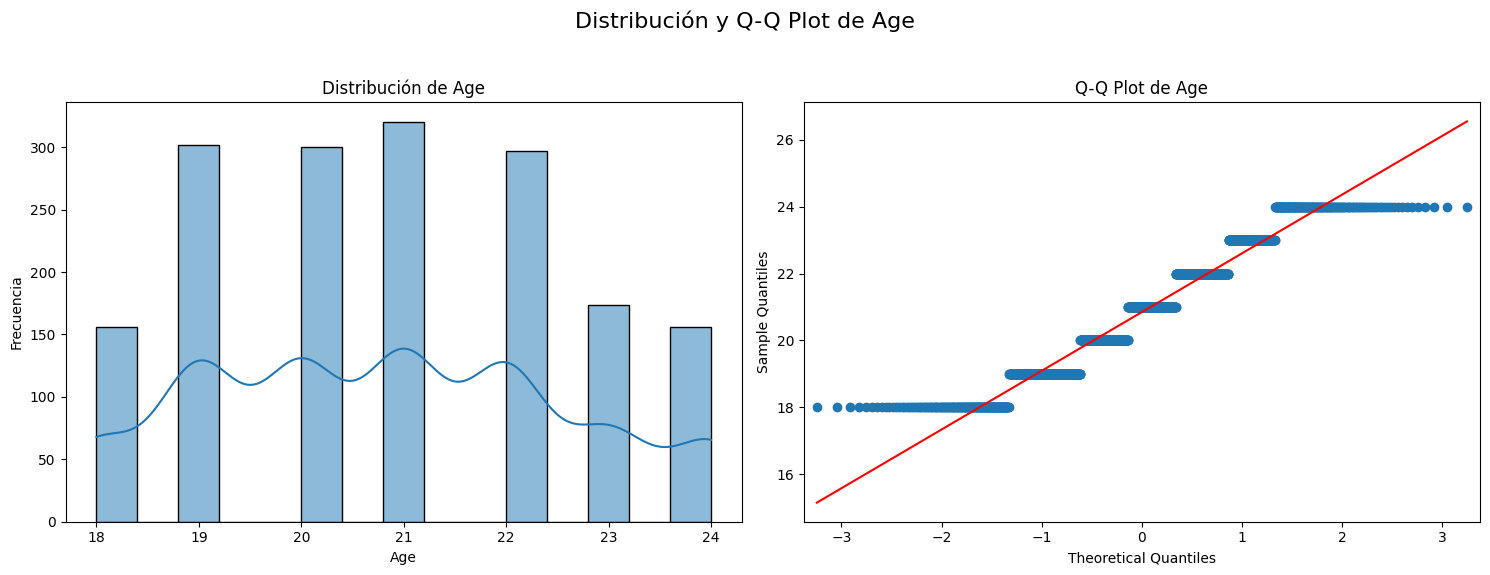

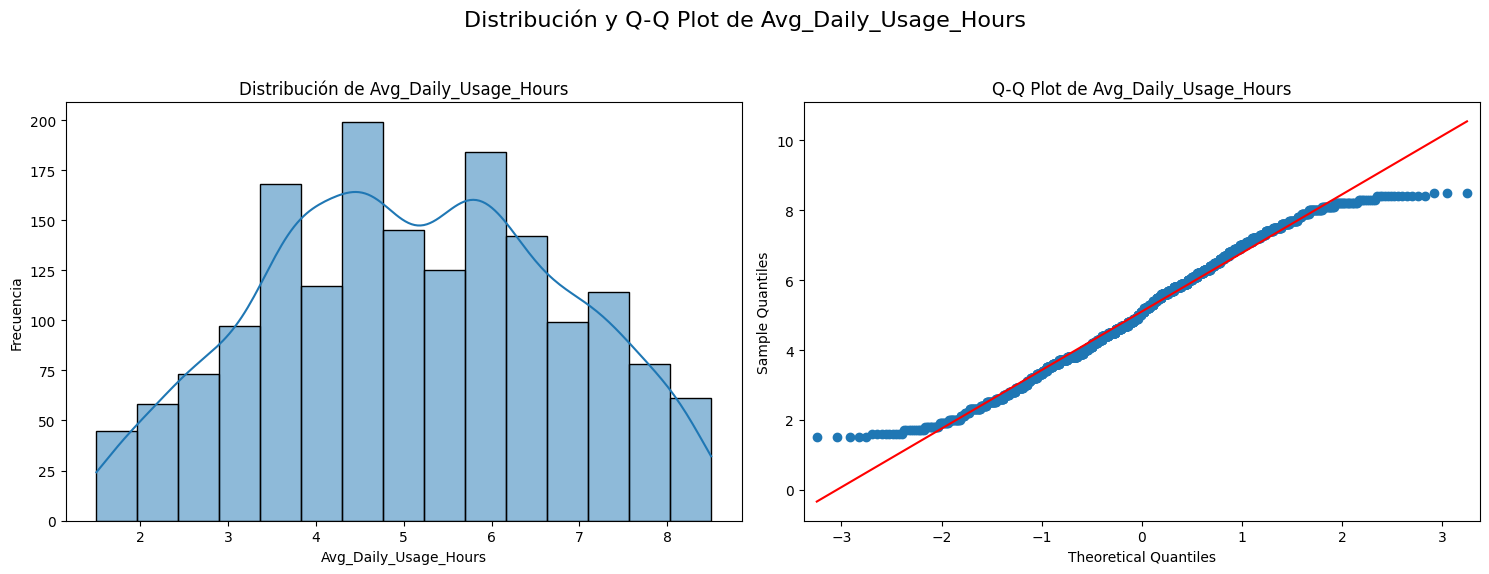

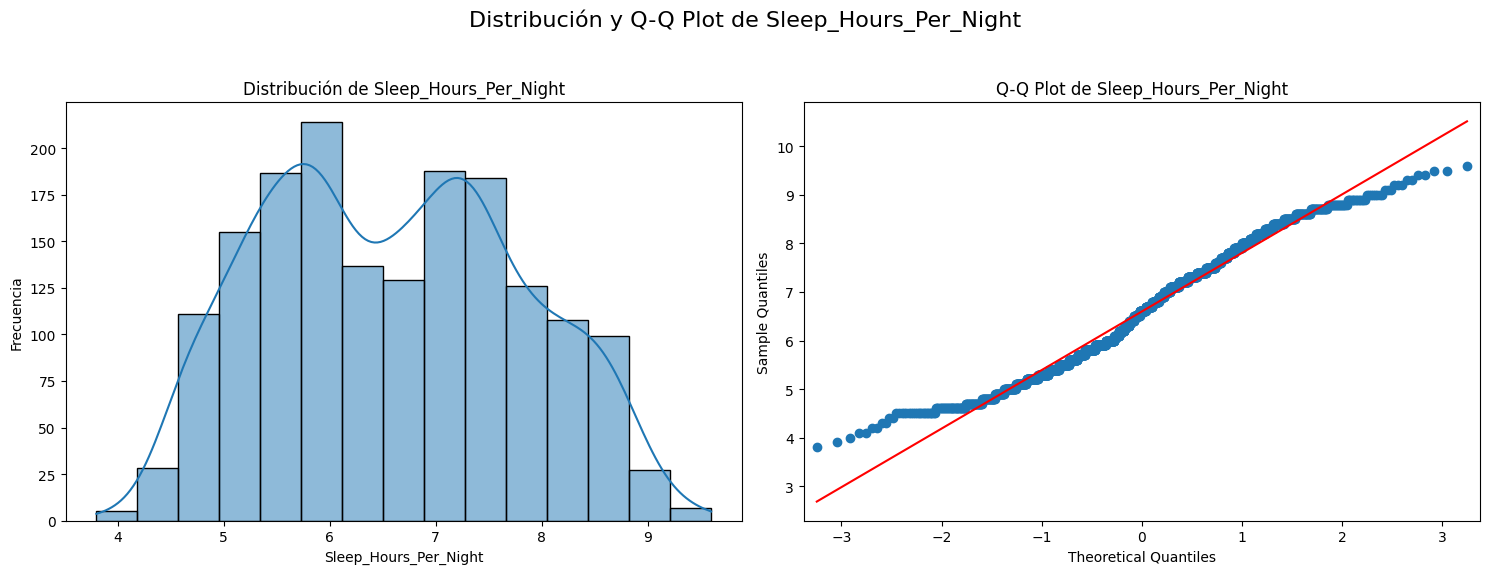

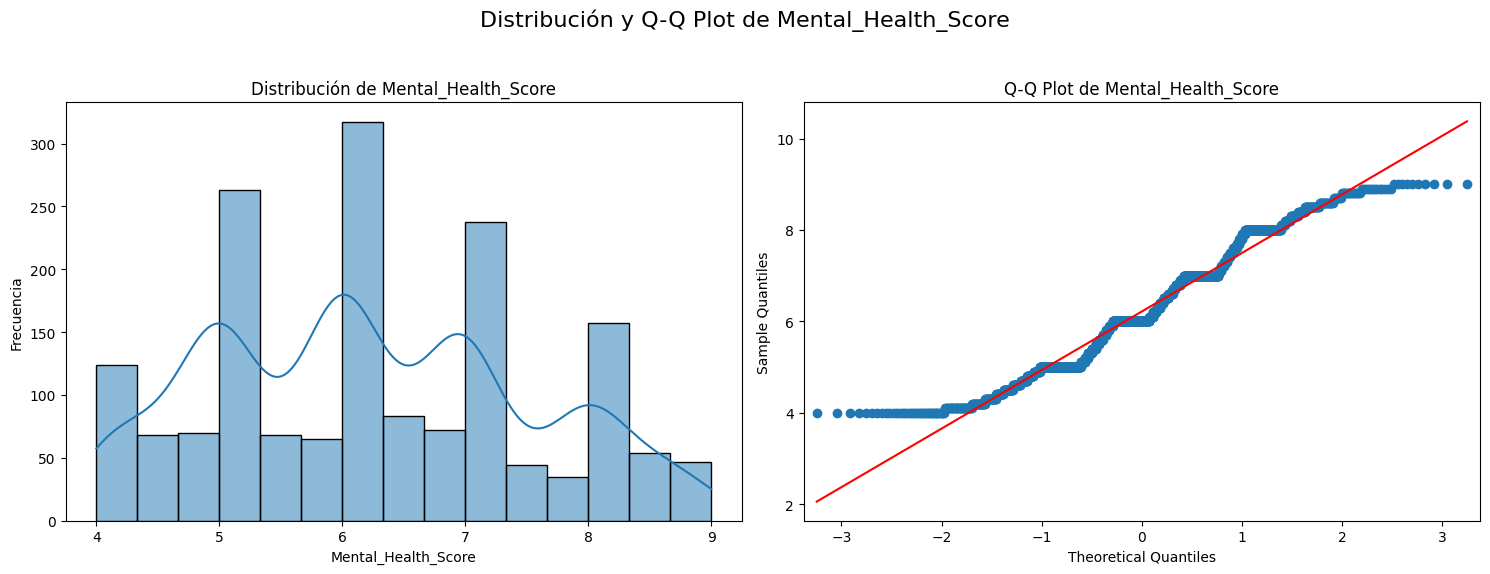

In [9]:
# Seleccionar las columnas numéricas para visualizar su distribución
numerical_columns = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']

# Crear histogramas y Q-Q plots para cada columna numérica
for col in numerical_columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Distribución y Q-Q Plot de {col}', fontsize=16)

    # Histograma con KDE
    sns.histplot(data[col], bins=15, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')

    # Q-Q plot
    sm.qqplot(data[col], line='s', ax=axes[1])
    axes[1].set_title(f'Q-Q Plot de {col}')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

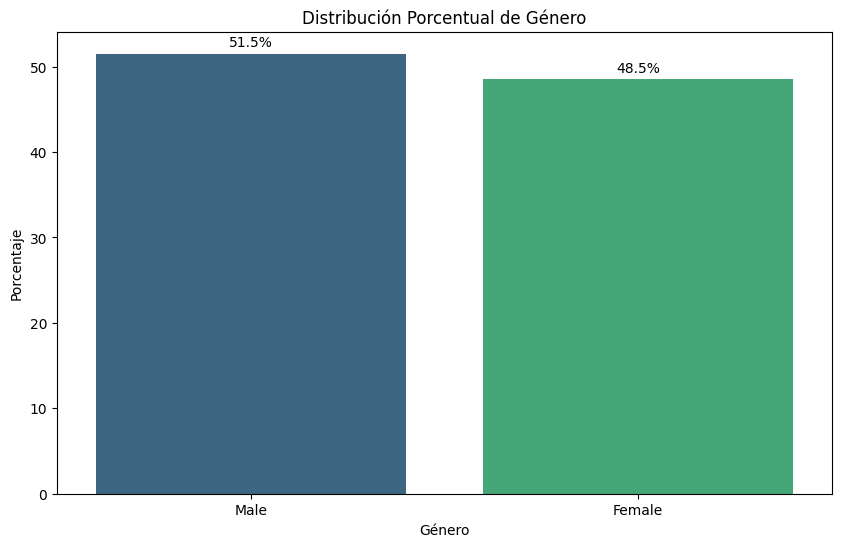

In [10]:
# Conteo por Género a porcentual
gender_counts = data['Gender'].value_counts()
gender_percentages = gender_counts / gender_counts.sum() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=gender_percentages.index, y=gender_percentages.values, palette='viridis', hue=gender_percentages.index, legend=False)
plt.title('Distribución Porcentual de Género')
plt.xlabel('Género')
plt.ylabel('Porcentaje')

# Añadir etiquetas de porcentaje en las barras
for index, value in enumerate(gender_percentages.values):
    plt.text(index, value + 0.5, f'{value:.1f}%', ha='center', va='bottom')

plt.show()

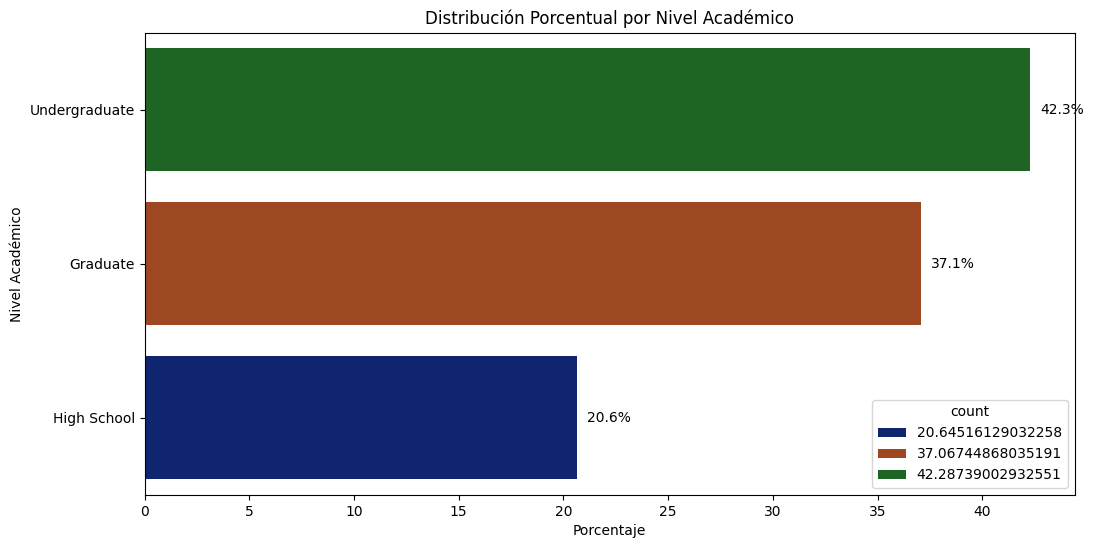

In [11]:
# Conteo por Nivel Académico (porcentual)
academic_level_counts = data['Academic_Level'].value_counts()
academic_level_percentages = (academic_level_counts / academic_level_counts.sum()) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=academic_level_percentages.values, y=academic_level_percentages.index,
            palette='dark' , hue = academic_level_percentages)

plt.title('Distribución Porcentual por Nivel Académico')
plt.xlabel('Porcentaje')
plt.ylabel('Nivel Académico')

# Añadir etiquetas de porcentaje en las barras
for index, value in enumerate(academic_level_percentages.values):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center')

plt.show()

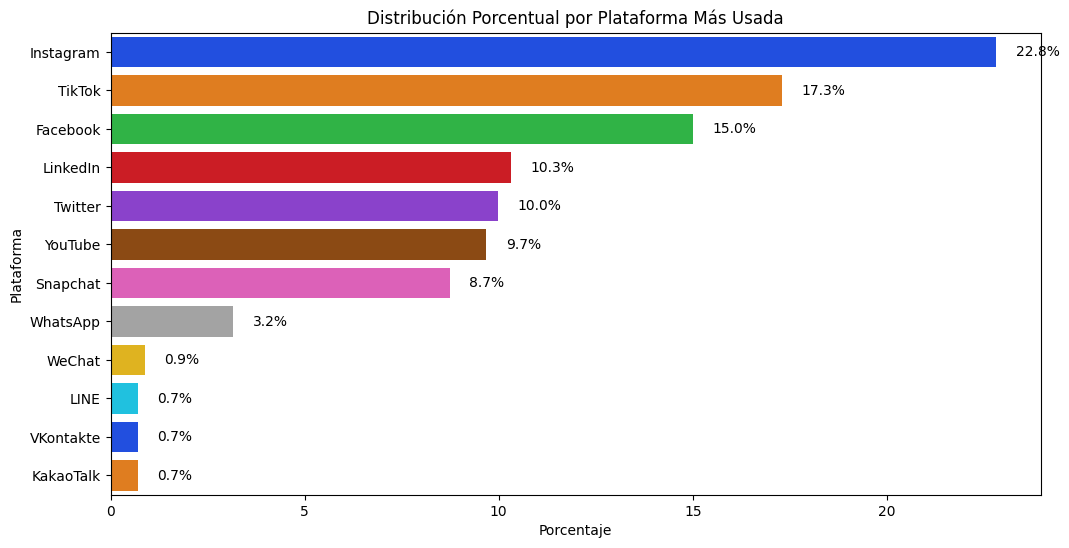

In [12]:
# Conteo por Plataforma Más Usada (porcentual)
most_used_platform_counts = data['Most_Used_Platform'].value_counts()
most_used_platform_percentages = (most_used_platform_counts / most_used_platform_counts.sum()) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=most_used_platform_percentages.values, y=most_used_platform_percentages.index,
            palette='bright', hue=most_used_platform_percentages.index, legend=False)
plt.title('Distribución Porcentual por Plataforma Más Usada')
plt.xlabel('Porcentaje')
plt.ylabel('Plataforma')

# Añadir etiquetas de porcentaje en las barras
for index, value in enumerate(most_used_platform_percentages.values):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center')

plt.show()

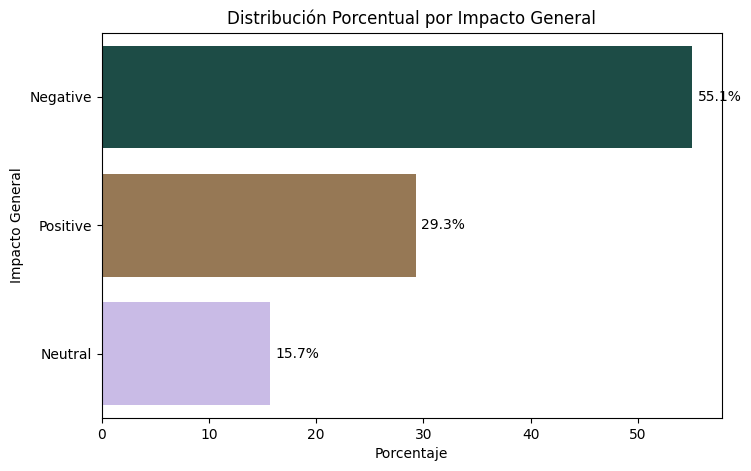

In [13]:
# Conteo por Impacto General (porcentual)
overall_impact_counts = data['Overall_Impact'].value_counts()
overall_impact_percentages = (overall_impact_counts / overall_impact_counts.sum()) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=overall_impact_percentages.values, y=overall_impact_percentages.index,
            palette='cubehelix', hue=overall_impact_percentages.index, legend=False)
plt.title('Distribución Porcentual por Impacto General')
plt.xlabel('Porcentaje')
plt.ylabel('Impacto General')

# Añadir etiquetas de porcentaje en las barras
for index, value in enumerate(overall_impact_percentages.values):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center')

plt.show()

In [14]:
# Crear un nuevo DataFrame sin las columnas especificadas
data2 = data.drop(columns=['Student_ID', 'Country'])

# Codificar la variable 'Gender'
gender_mapping = {'Male': 0, 'Female': 1}
data2['Gender'] = data2['Gender'].map(gender_mapping)

# Codificar la variable 'Academic_Level'
academic_level_mapping = {'High School': 0, 'Undergraduate': 1, 'Graduate': 2}
data2['Academic_Level'] = data2['Academic_Level'].map(academic_level_mapping)

# Codificar la variable 'Affects_Academic_Performance'
affects_academic_performance_mapping = {'No': 0, 'Yes': 1}
data2['Affects_Academic_Performance'] = data2['Affects_Academic_Performance'].map(affects_academic_performance_mapping)

# Codificar la variable 'Overall_Impact'
overall_impact_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
data2['Overall_Impact'] = data2['Overall_Impact'].map(overall_impact_mapping)

# Codificar la variable 'Most_Used_Platform'
Most_Used_Platform_mapping = {'Instagram': 0, 'TikTok': 1, 'Facebook': 2,
                              'LinkedIn': 3, 'Twitter': 4, 'YouTube': 5,
                              'Snapchat': 6, 'WhatsApp': 7, 'WeChat': 8,
                              'LINE': 9, 'VKontakte': 10, 'KakaoTalk': 11}
data2['Most_Used_Platform'] = data2['Most_Used_Platform'].map(Most_Used_Platform_mapping)

# Definir las columnas a mover al final
columns_to_move = ['Affects_Academic_Performance', 'Overall_Impact', 'Mental_Health_Score']

# Obtener las columnas actuales que no se van a mover
other_columns = [col for col in data2.columns if col not in columns_to_move]

# Reordenar el DataFrame
data2 = data2[other_columns + columns_to_move]

# Mostrar las primeras filas del nuevo DataFrame procesado
print("DataFrame después de eliminar columnas, codificar variables y reordenar:")
display(data2.head())

DataFrame después de eliminar columnas, codificar variables y reordenar:


,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Sleep_Hours_Per_Night,Affects_Academic_Performance,Overall_Impact,Mental_Health_Score
0,21,0,1,4.0,2,6.7,0,1,6.8
1,23,1,1,1.6,3,8.6,0,2,7.6
2,22,0,2,4.6,0,6.7,0,1,7.0
3,18,0,1,7.0,6,5.4,1,0,5.3
4,24,1,0,7.5,2,5.0,1,0,4.4


# 3. Analisis Inferencial

Vamos a hacer una matriz de correlación de Spearman para poder mirar la relación entre las variables y saber con cuáles hacer la regresión. Esta matriz muestra el coeficiente de correlación de Pearson entre cada par de variables, indicando la fuerza y dirección de su relación lineal. Un valor cercano a 1 o -1 indica una fuerte correlación positiva o negativa, respectivamente, mientras que un valor cercano a 0 indica poca o ninguna correlación lineal.
Para este caso se va a tomar la variable "Mental_Health_Score" como la variable Independiente y para visualizarlo mejor la vamos a poner al final de la tabla.

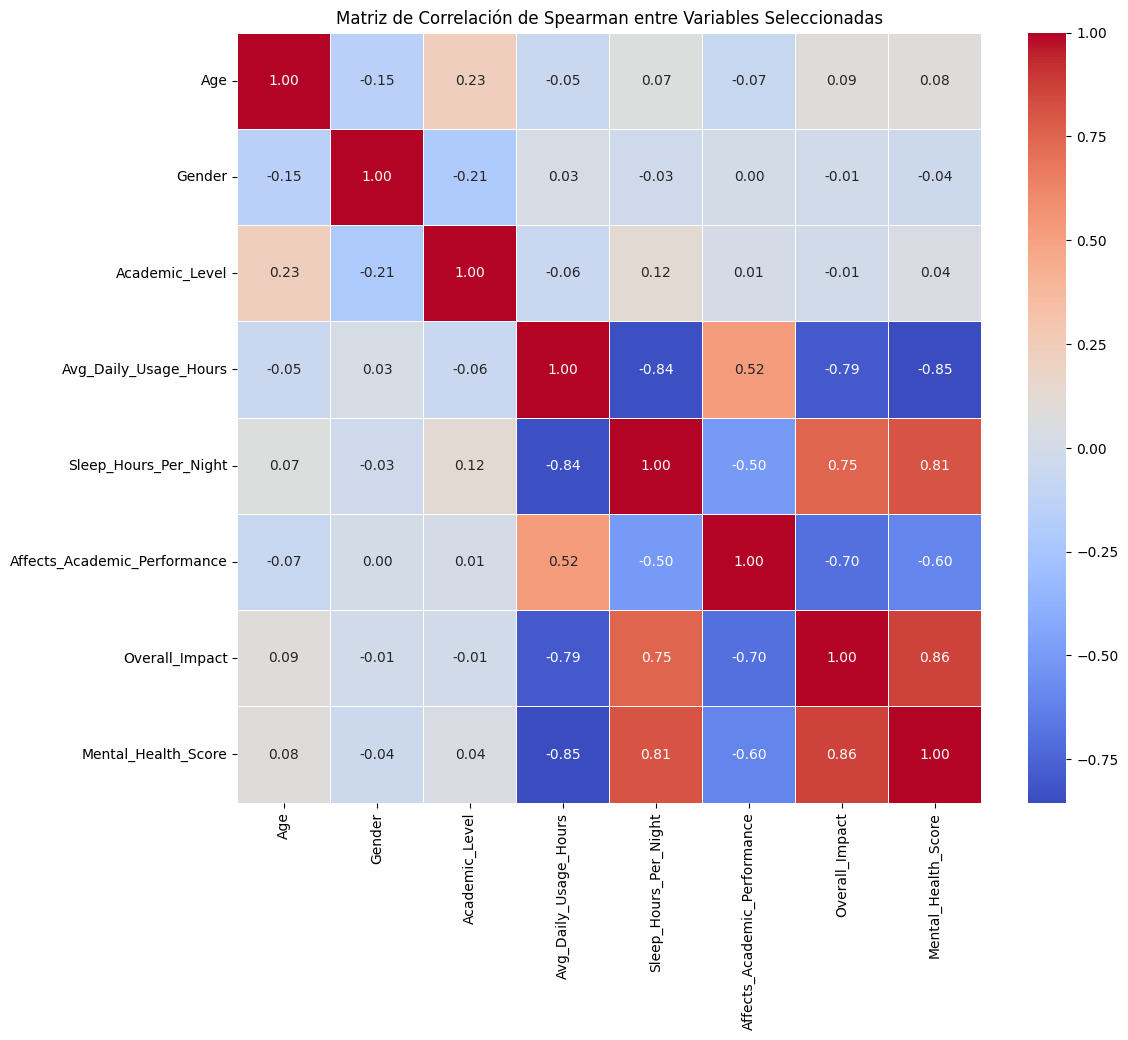


Matriz de Correlación de Spearman:


,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Affects_Academic_Performance,Overall_Impact,Mental_Health_Score
Age,1.000000,-0.148433,0.230493,-0.052601,0.071052,-0.067767,0.088380,0.083237
Gender,-0.148433,1.000000,-0.205645,0.028853,-0.027338,0.001482,-0.011397,-0.041024
Academic_Level,0.230493,-0.205645,1.000000,-0.063399,0.119394,0.011307,-0.012502,0.041008
Avg_Daily_Usage_Hours,-0.052601,0.028853,-0.063399,1.000000,-0.838855,0.523084,-0.793177,-0.854601
Sleep_Hours_Per_Night,0.071052,-0.027338,0.119394,-0.838855,1.000000,-0.501734,0.748999,0.808669
Affects_Academic_Performance,-0.067767,0.001482,0.011307,0.523084,-0.501734,1.000000,-0.696084,-0.604473
Overall_Impact,0.088380,-0.011397,-0.012502,-0.793177,0.748999,-0.696084,1.000000,0.862963
Mental_Health_Score,0.083237,-0.041024,0.041008,-0.854601,0.808669,-0.604473,0.862963,1.000000


In [15]:
# Seleccionar las columnas para la matriz de correlación de Spearman
spearman_columns = [
    'Age',
    'Gender',
    'Academic_Level',
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours_Per_Night',
    'Affects_Academic_Performance',
    'Overall_Impact',
    'Mental_Health_Score'
]

# Filtrar el DataFrame data2 con las columnas seleccionadas
data_for_spearman = data2[spearman_columns]

# Calcular la matriz de correlación de Spearman
spearman_corr_matrix = data_for_spearman.corr(method='spearman')

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Spearman entre Variables Seleccionadas')
plt.show()

print("\nMatriz de Correlación de Spearman:")
display(spearman_corr_matrix)

Mental_Health_Score muestra una fuerte correlación negativa con Avg_Daily_Usage_Hours (-0.85) y una fuerte correlación positiva con Sleep_Hours_Per_Night (0.81). Esto sugiere que un mayor uso de redes sociales se asocia con una menor puntuación de salud mental, mientras que más horas de sueño se asocian con una mayor puntuación de salud mental.

Overall_Impact también está fuertemente correlacionado negativamente con Mental_Health_Score (0.86) mostrando que un impacto general positivo podría reflejar una alta salud mental.
Por otro lado, se encontró una correlacion negativa moderada con Affects_Academic_Performance y Mental_Health_Score, lo que sugiere que cuando el performance academico no se afecta el puntaje de salud tambien resulta mayor (-0.60)

Las variables Age, Gender y Academic_Level muestran correlaciones relativamente bajas con las otras variables, indicando que su relación no es tan lineal o monótona como las anteriores.

El mapa de calor proporciona una representación visual de estas correlaciones, donde los colores más cálidos (rojo) indican correlaciones positivas y los más fríos (azul) indican correlaciones negativas, con la intensidad del color reflejando la fuerza de la correlación.

### 3.2 Matriz de Correlación para Variables Numéricas

Vamos a hacer una matriz de correlación solo con las variables que mostraron alta correlación, para que sea mas facil de identificar. .

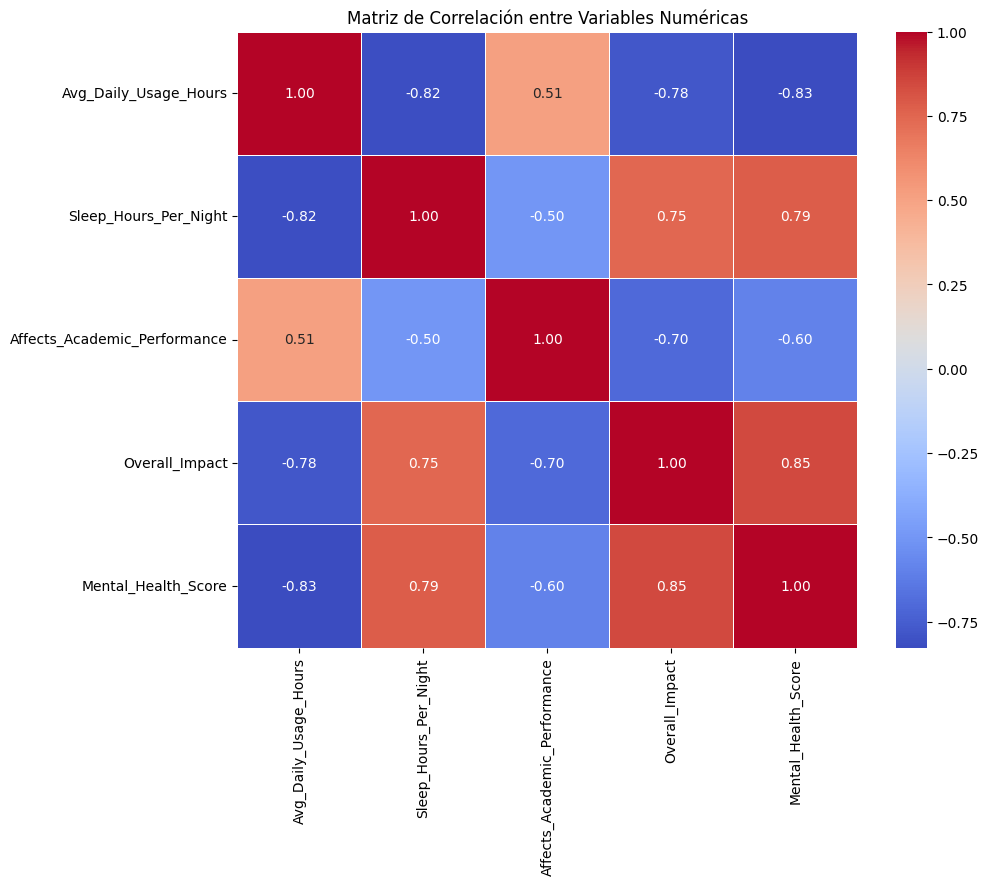

In [16]:

# Seleccionar las columnas numéricas solicitadas
correlacion = data2[['Avg_Daily_Usage_Hours',
                    'Sleep_Hours_Per_Night',
                     'Affects_Academic_Performance',
                     'Overall_Impact',
                     'Mental_Health_Score']]

# Calcular la matriz de correlación
correlation_matrix = correlacion.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()


## 4. Modelos de Regresión Lineal Simple para Diferentes Variables Predictoras


--- Modelo de Regresión Lineal para Avg_Daily_Usage_Hours ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.685
Model:                             OLS   Adj. R-squared:                  0.685
Method:                  Least Squares   F-statistic:                     2964.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:07   Log-Likelihood:                -1482.0
No. Observations:                 1364   AIC:                             2968.
Df Residuals:                     1362   BIC:                             2978.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

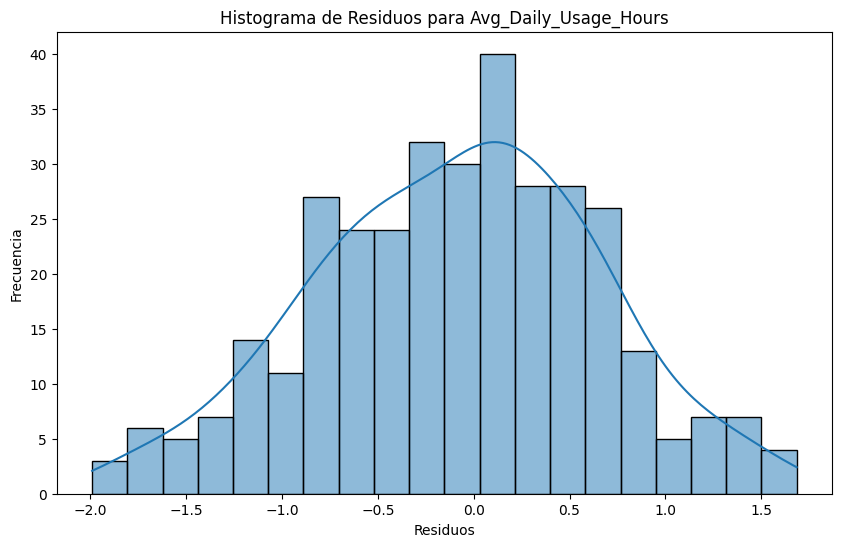


--- Modelo de Regresión Lineal para Sleep_Hours_Per_Night ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.621
Model:                             OLS   Adj. R-squared:                  0.621
Method:                  Least Squares   F-statistic:                     2234.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):          1.93e-289
Time:                         21:24:08   Log-Likelihood:                -1608.1
No. Observations:                 1364   AIC:                             3220.
Df Residuals:                     1362   BIC:                             3231.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

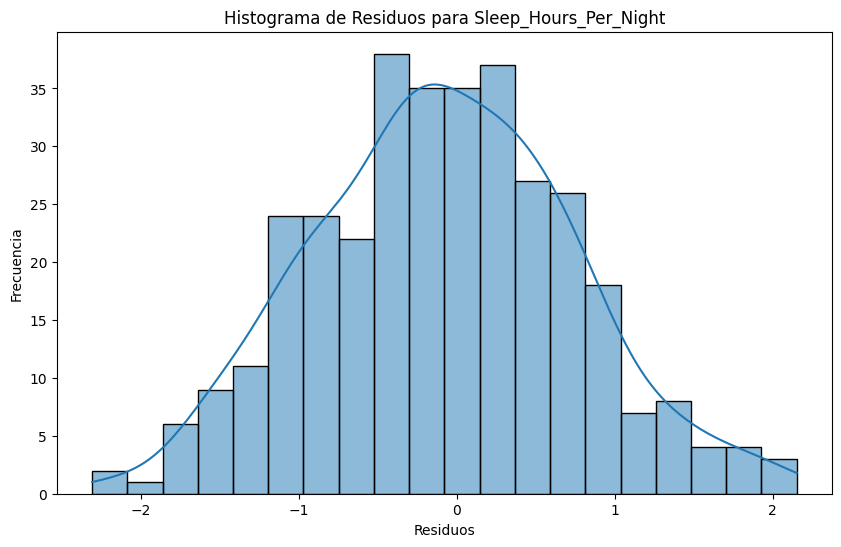


--- Modelo de Regresión Lineal para Affects_Academic_Performance ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.366
Model:                             OLS   Adj. R-squared:                  0.365
Method:                  Least Squares   F-statistic:                     785.7
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):          7.20e-137
Time:                         21:24:08   Log-Likelihood:                -1959.6
No. Observations:                 1364   AIC:                             3923.
Df Residuals:                     1362   BIC:                             3934.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------

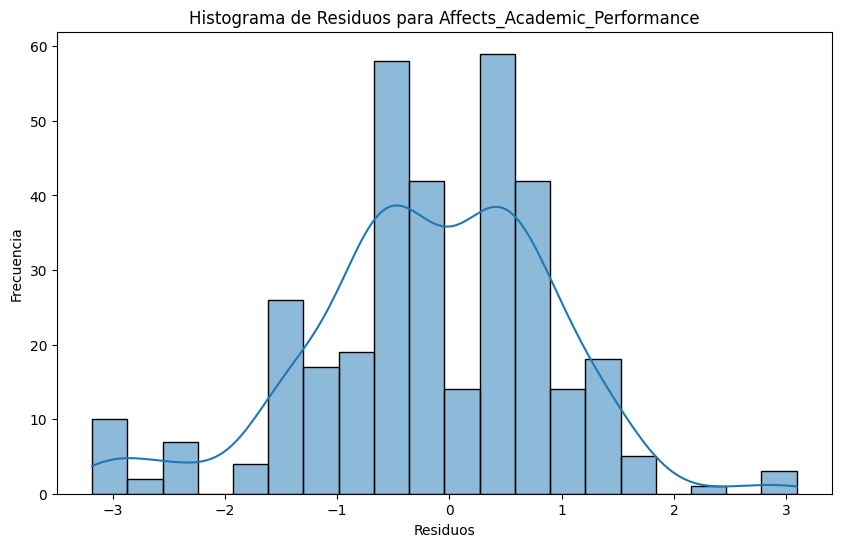


--- Modelo de Regresión Lineal para Overall_Impact ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.717
Model:                             OLS   Adj. R-squared:                  0.717
Method:                  Least Squares   F-statistic:                     3457.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:08   Log-Likelihood:                -1408.5
No. Observations:                 1364   AIC:                             2821.
Df Residuals:                     1362   BIC:                             2831.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

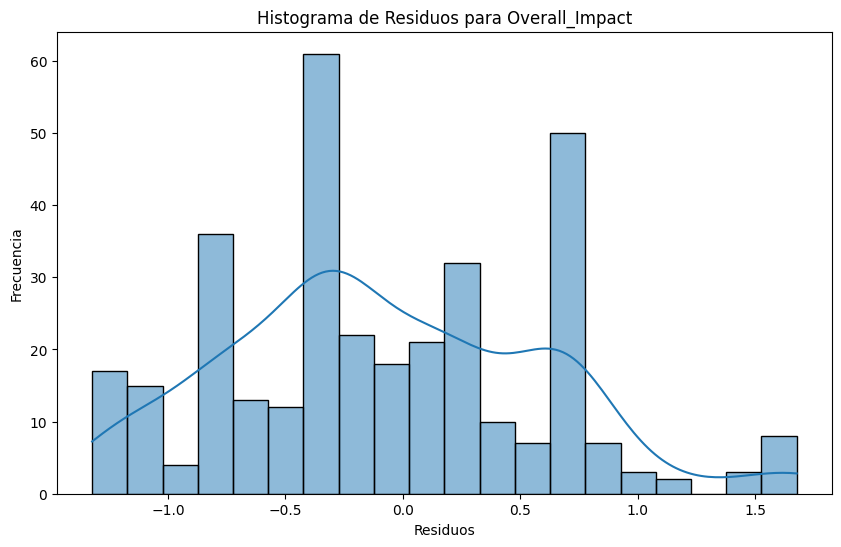

In [17]:
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

independent_variables = [
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours_Per_Night',
    'Affects_Academic_Performance',
    'Overall_Impact'
]

def run_simple_linear_regression(df, dependent_var, independent_var):
    print(f"\n--- Modelo de Regresión Lineal para {independent_var} ---")

    X = df[[independent_var]]
    Y = df[dependent_var]

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    train_data = pd.DataFrame(X_train)
    train_data[dependent_var] = Y_train

    formula = f'{dependent_var} ~ {independent_var}'
    model = smf.ols(formula, data=train_data).fit()

    print("\nResumen del Modelo:")
    print(model.summary())

    Y_pred = model.predict(X_test)

    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)
    MAPE = np.nanmean( np.abs((Y-Y_pred) / Y.replace(0, np.nan))) * 100

    print("\nMetricas de Evaluación del Modelo:")
    print(f"Error Medio Cuadrático (MSE): {mse:.4f}")
    print(f"Raíz del Error Medio Cuadrático (RMSE): {rmse:.4f}")
    print(f"Error Absoluto Medio (MAE): {mae:.4f}")
    print(f"R-cuadrado (R2): {r2:.4f}")
    print(f"MAPE: {MAPE:.2f}%")

    # Plot histogram of residuals
    residuals = Y_test - Y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, kde=True, bins=20)
    plt.title(f'Histograma de Residuos para {independent_var}')
    plt.xlabel('Residuos')
    plt.ylabel('Frecuencia')
    plt.show()

for var in independent_variables:
    run_simple_linear_regression(data2, 'Mental_Health_Score', var)


### 4.2. Modelos de Regresión Lineal Múltiple para Combinaciones de 2 Variables Predictoras


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Avg_Daily_Usage_Hours + Sleep_Hours_Per_Night ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.722
Model:                             OLS   Adj. R-squared:                  0.721
Method:                  Least Squares   F-statistic:                     1766.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:08   Log-Likelihood:                -1397.6
No. Observations:                 1364   AIC:                             2801.
Df Residuals:                     1361   BIC:                             2817.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|

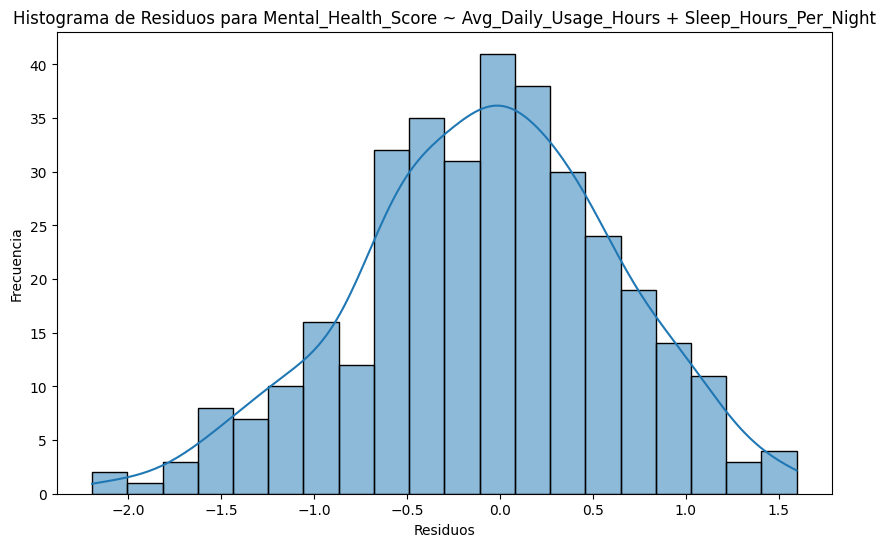


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Avg_Daily_Usage_Hours + Affects_Academic_Performance ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.728
Model:                             OLS   Adj. R-squared:                  0.728
Method:                  Least Squares   F-statistic:                     1823.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:09   Log-Likelihood:                -1381.9
No. Observations:                 1364   AIC:                             2770.
Df Residuals:                     1361   BIC:                             2786.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                   coef    std err        

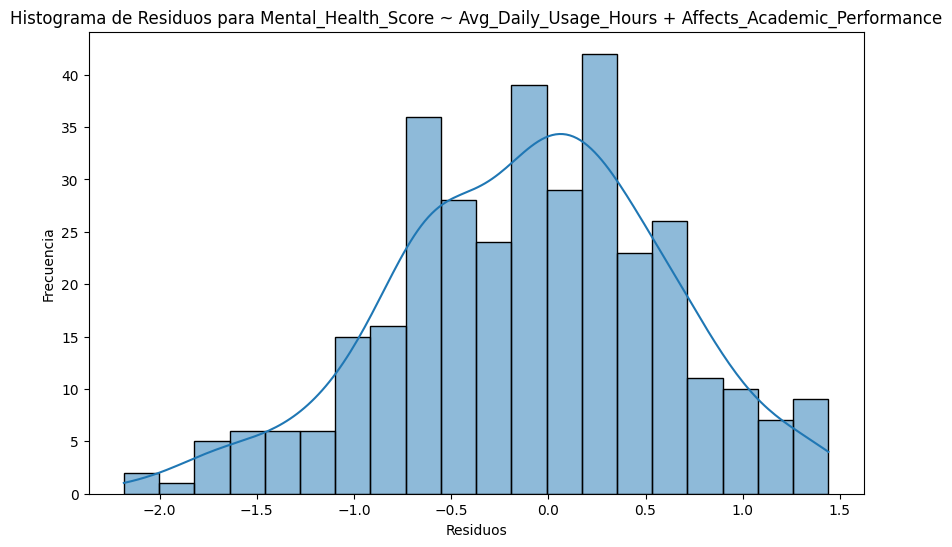


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Avg_Daily_Usage_Hours + Overall_Impact ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.789
Model:                             OLS   Adj. R-squared:                  0.789
Method:                  Least Squares   F-statistic:                     2545.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:09   Log-Likelihood:                -1209.1
No. Observations:                 1364   AIC:                             2424.
Df Residuals:                     1361   BIC:                             2440.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [

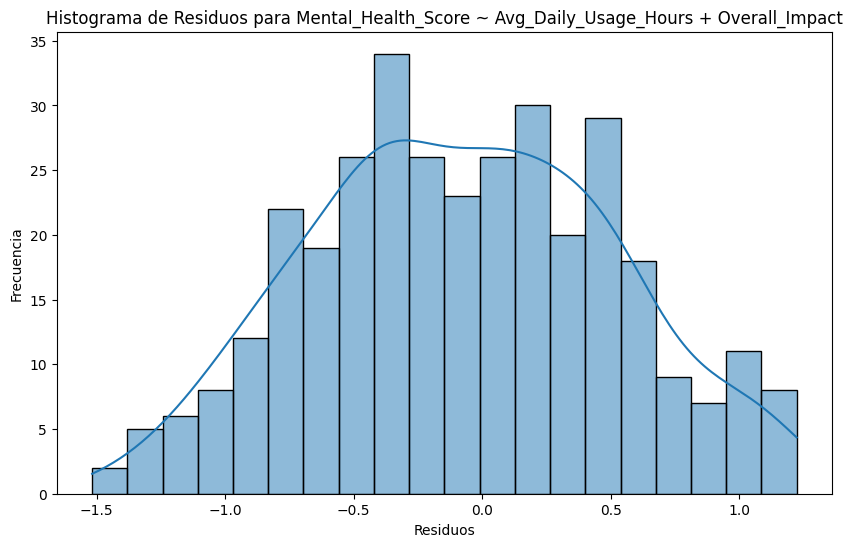


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Sleep_Hours_Per_Night + Affects_Academic_Performance ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.677
Model:                             OLS   Adj. R-squared:                  0.677
Method:                  Least Squares   F-statistic:                     1428.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:09   Log-Likelihood:                -1499.1
No. Observations:                 1364   AIC:                             3004.
Df Residuals:                     1361   BIC:                             3020.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                   coef    std err        

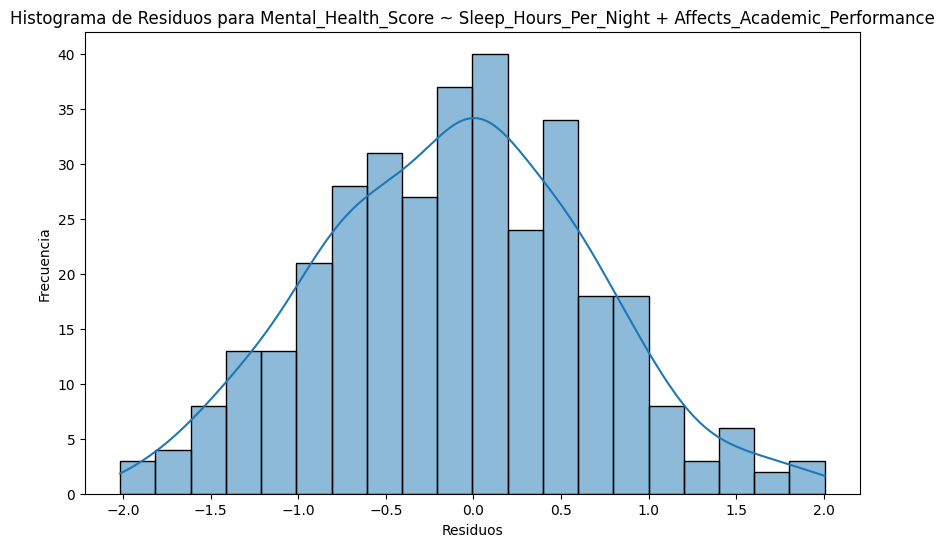


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Sleep_Hours_Per_Night + Overall_Impact ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.770
Model:                             OLS   Adj. R-squared:                  0.770
Method:                  Least Squares   F-statistic:                     2277.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:09   Log-Likelihood:                -1268.2
No. Observations:                 1364   AIC:                             2542.
Df Residuals:                     1361   BIC:                             2558.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [

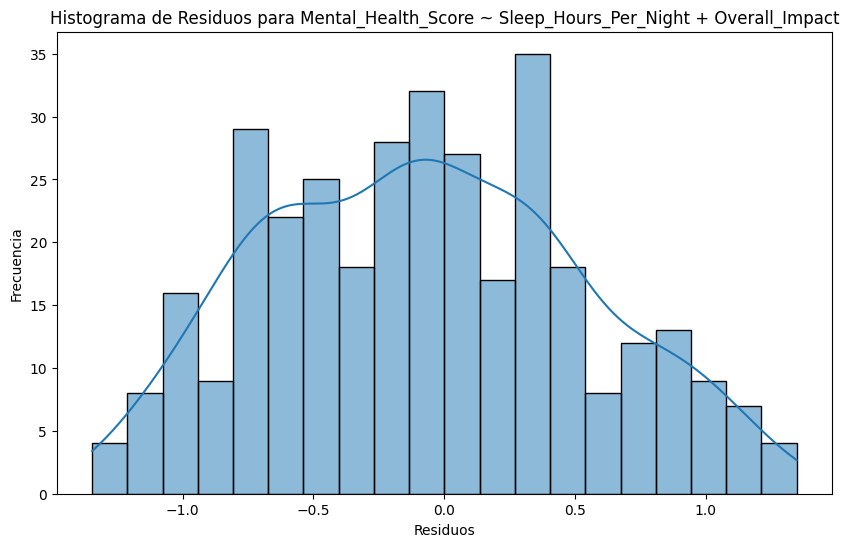


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Affects_Academic_Performance + Overall_Impact ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.718
Model:                             OLS   Adj. R-squared:                  0.717
Method:                  Least Squares   F-statistic:                     1730.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:10   Log-Likelihood:                -1407.6
No. Observations:                 1364   AIC:                             2821.
Df Residuals:                     1361   BIC:                             2837.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                                   coef    std err          t    

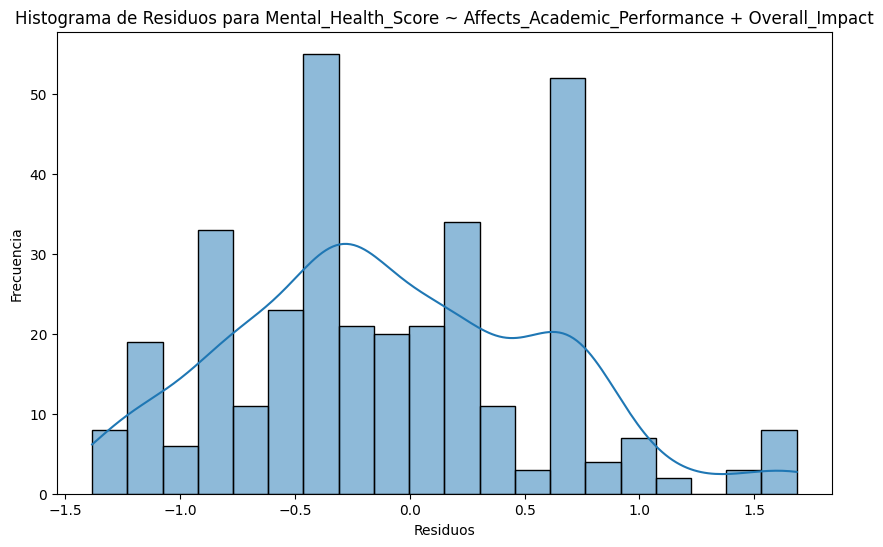

In [18]:
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dependent_variable = 'Mental_Health_Score'
independent_variables_list = [
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours_Per_Night',
    'Affects_Academic_Performance',
    'Overall_Impact'
]

# Generar todas las combinaciones posibles de dos variables independientes
combinations = list(itertools.combinations(independent_variables_list, 2))

for var1, var2 in combinations:
    print(f"\n--- Modelo de Regresión Lineal Múltiple: {dependent_variable} ~ {var1} + {var2} ---")

    # Seleccionar las variables para este modelo
    X = data2[[var1, var2]]
    Y = data2[dependent_variable]

    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    # Crear un DataFrame para el modelo statsmodels que incluya la variable dependiente
    train_data = pd.DataFrame(X_train)
    train_data[dependent_variable] = Y_train

    # Construir el modelo de regresión lineal múltiple usando statsmodels
    formula = f'{dependent_variable} ~ {var1} + {var2}'
    model = smf.ols(formula, data=train_data).fit()

    print("\nResumen del Modelo:")
    print(model.summary())

    # Realizar predicciones en el conjunto de prueba
    Y_pred = model.predict(X_test)

    # Calcular las métricas de evaluación
    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)
    MAPE = np.nanmean( np.abs((Y_test - Y_pred) / Y_test.replace(0, np.nan))) * 100

    print("\nMetricas de Evaluación del Modelo:")
    print(f"Error Medio Cuadrático (MSE): {mse:.4f}")
    print(f"Raíz del Error Medio Cuadrático (RMSE): {rmse:.4f}")
    print(f"Error Absoluto Medio (MAE): {mae:.4f}")
    print(f"R-cuadrado (R2): {r2:.4f}")
    print(f"MAPE: {MAPE:.2f}%")

    # Plot histogram of residuals
    residuals = Y_test - Y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, kde=True, bins=20)
    plt.title(f'Histograma de Residuos para {dependent_variable} ~ {var1} + {var2}')
    plt.xlabel('Residuos')
    plt.ylabel('Frecuencia')
    plt.show()


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Avg_Daily_Usage_Hours + Sleep_Hours_Per_Night + Affects_Academic_Performance ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.753
Model:                             OLS   Adj. R-squared:                  0.752
Method:                  Least Squares   F-statistic:                     1382.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:10   Log-Likelihood:                -1316.6
No. Observations:                 1364   AIC:                             2641.
Df Residuals:                     1360   BIC:                             2662.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                  

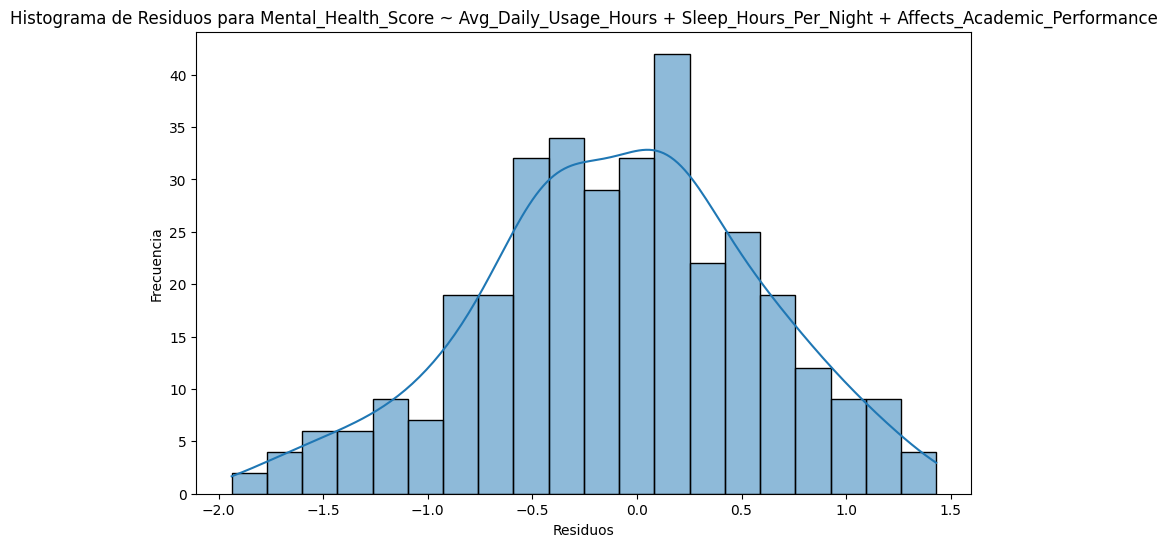


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Avg_Daily_Usage_Hours + Sleep_Hours_Per_Night + Overall_Impact ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.798
Model:                             OLS   Adj. R-squared:                  0.797
Method:                  Least Squares   F-statistic:                     1790.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:10   Log-Likelihood:                -1179.7
No. Observations:                 1364   AIC:                             2367.
Df Residuals:                     1360   BIC:                             2388.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                            coef    std err     

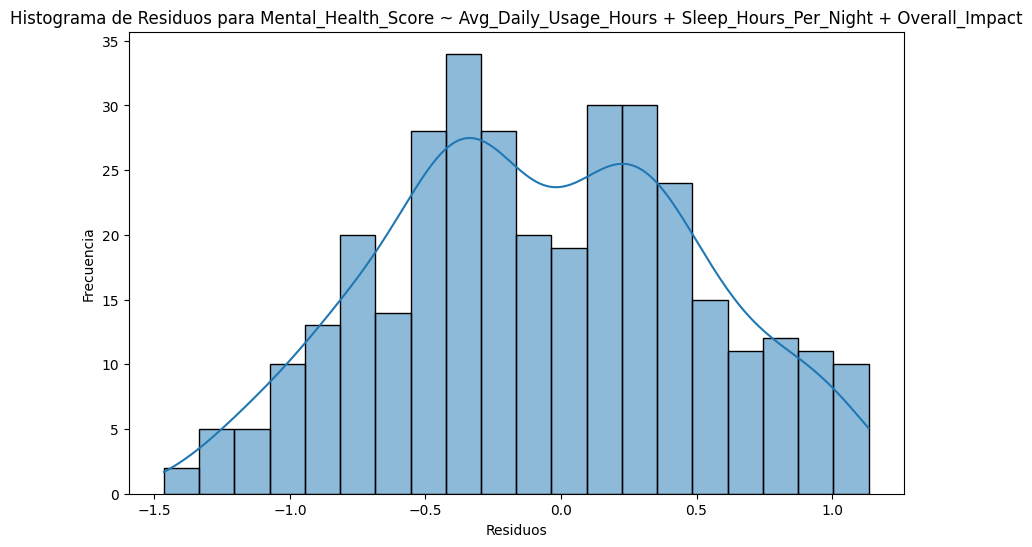


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Avg_Daily_Usage_Hours + Affects_Academic_Performance + Overall_Impact ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.790
Model:                             OLS   Adj. R-squared:                  0.790
Method:                  Least Squares   F-statistic:                     1708.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:10   Log-Likelihood:                -1205.0
No. Observations:                 1364   AIC:                             2418.
Df Residuals:                     1360   BIC:                             2439.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                   coef  

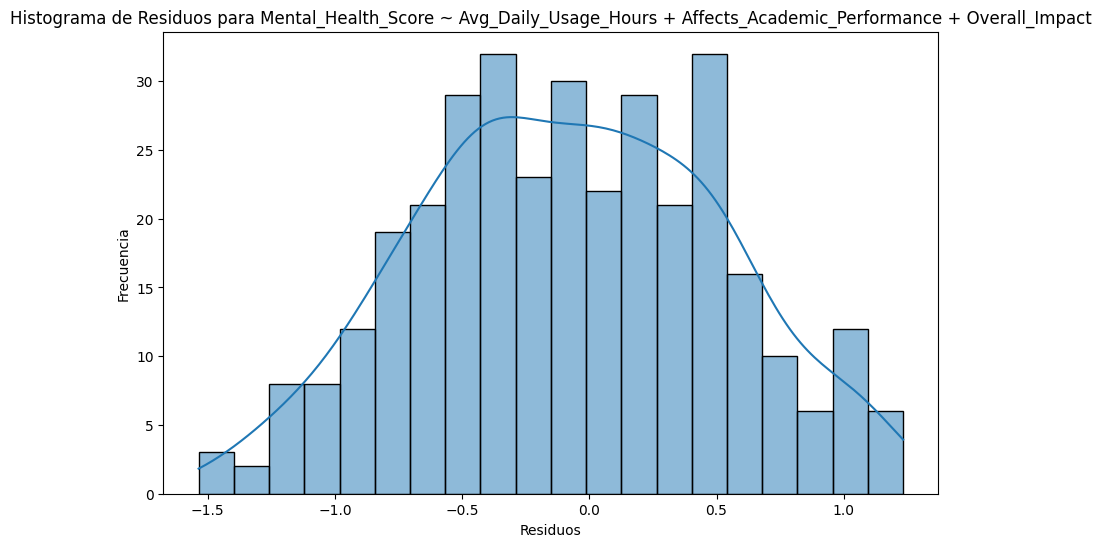


--- Modelo de Regresión Lineal Múltiple: Mental_Health_Score ~ Sleep_Hours_Per_Night + Affects_Academic_Performance + Overall_Impact ---

Resumen del Modelo:
                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.771
Model:                             OLS   Adj. R-squared:                  0.770
Method:                  Least Squares   F-statistic:                     1523.
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         21:24:11   Log-Likelihood:                -1266.1
No. Observations:                 1364   AIC:                             2540.
Df Residuals:                     1360   BIC:                             2561.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                   coef  

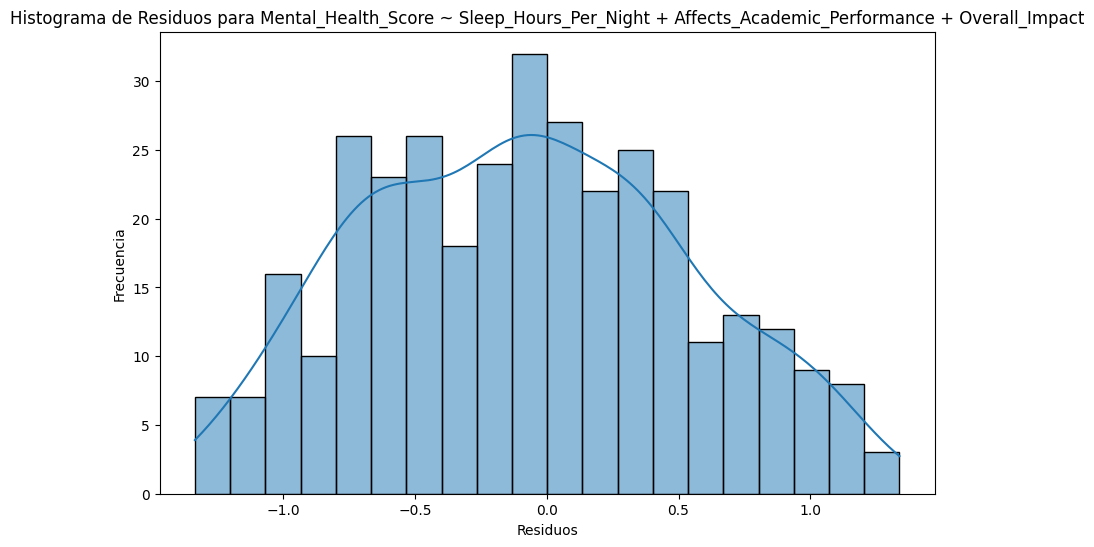

In [19]:
dependent_variable = 'Mental_Health_Score'
independent_variables_list = [
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours_Per_Night',
    'Affects_Academic_Performance',
    'Overall_Impact'
]

# Generar todas las combinaciones posibles de tres variables independientes
combinations = list(itertools.combinations(independent_variables_list, 3))

for var1, var2, var3 in combinations:
    print(f"\n--- Modelo de Regresión Lineal Múltiple: {dependent_variable} ~ {var1} + {var2} + {var3} ---")

    # Seleccionar las variables para este modelo
    X = data2[[var1, var2, var3]]
    Y = data2[dependent_variable]

    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    # Crear un DataFrame para el modelo statsmodels que incluya la variable dependiente
    train_data = pd.DataFrame(X_train)
    train_data[dependent_variable] = Y_train

    # Construir el modelo de regresión lineal múltiple usando statsmodels
    formula = f'{dependent_variable} ~ {var1} + {var2} + {var3}'
    model = smf.ols(formula, data=train_data).fit()

    print("\nResumen del Modelo:")
    print(model.summary())

    # Realizar predicciones en el conjunto de prueba
    Y_pred = model.predict(X_test)

    # Calcular las métricas de evaluación
    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)
    MAPE = np.nanmean( np.abs((Y_test - Y_pred) / Y_test.replace(0, np.nan))) * 100

    print("\nMetricas de Evaluación del Modelo:")
    print(f"Error Medio Cuadrático (MSE): {mse:.4f}")
    print(f"Raíz del Error Medio Cuadrático (RMSE): {rmse:.4f}")
    print(f"Error Absoluto Medio (MAE): {mae:.4f}")
    print(f"R-cuadrado (R2): {r2:.4f}")
    print(f"MAPE: {MAPE:.2f}%")

    # Plot histogram of residuals
    residuals = Y_test - Y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, kde=True, bins=20)
    plt.title(f'Histograma de Residuos para {dependent_variable} ~ {var1} + {var2} + {var3}')
    plt.xlabel('Residuos')
    plt.ylabel('Frecuencia')
    plt.show()

### 4.4. Tabla Comparativa de Métricas de Modelos de Regresión Lineal

In [20]:
import pandas as pd

# Data for Simple Linear Regression Models (from previous outputs)
simple_lr_metrics = {
    'Modelo': [
        'Mental_Health_Score ~ Avg_Daily_Usage_Hours',
        'Mental_Health_Score ~ Sleep_Hours_Per_Night',
        'Mental_Health_Score ~ Affects_Academic_Performance',
        'Mental_Health_Score ~ Overall_Impact'
    ],
    'MSE': [0.5511, 0.6771, 1.1725, 0.3831],
    'RMSE': [0.7424, 0.8229, 1.0828, 0.6190],
    'MAE': [0.5973, 0.6603, 0.8498, 0.5088],
    'R2': [0.6694, 0.5938, 0.2967, 0.7741],
    'MAPE': [10.63, 11.54, 15.43, 8.99]
}
simple_lr_df = pd.DataFrame(simple_lr_metrics)

# Data for Multiple Linear Regression Models (2 Independent Variables)
multi_lr_2var_metrics = {
    'Modelo': [
        'Mental_Health_Score ~ Avg_Daily_Usage_Hours + Sleep_Hours_Per_Night',
        'Mental_Health_Score ~ Avg_Daily_Usage_Hours + Affects_Academic_Performance',
        'Mental_Health_Score ~ Avg_Daily_Usage_Hours + Overall_Impact',
        'Mental_Health_Score ~ Sleep_Hours_Per_Night + Affects_Academic_Performance',
        'Mental_Health_Score ~ Sleep_Hours_Per_Night + Overall_Impact',
        'Mental_Health_Score ~ Affects_Academic_Performance + Overall_Impact'
    ],
    'MSE': [0.4916, 0.5001, 0.3505, 0.5750, 0.3703, 0.3766],
    'RMSE': [0.7011, 0.7072, 0.5920, 0.7583, 0.6085, 0.6137],
    'MAE': [0.5551, 0.5596, 0.4873, 0.6120, 0.4998, 0.5088],
    'R2': [0.7051, 0.7000, 0.7898, 0.6558, 0.7788, 0.7741],
    'MAPE': [9.87, 10.06, 8.65, 10.82, 8.79, 8.99]
}
multi_lr_2var_df = pd.DataFrame(multi_lr_2var_metrics)

# Data for Multiple Linear Regression Models (3 Independent Variables)
multi_lr_3var_metrics = {
    'Modelo': [
        'Mental_Health_Score ~ Avg_Daily_Usage_Hours + Sleep_Hours_Per_Night + Affects_Academic_Performance',
        'Mental_Health_Score ~ Avg_Daily_Usage_Hours + Sleep_Hours_Per_Night + Overall_Impact',
        'Mental_Health_Score ~ Avg_Daily_Usage_Hours + Affects_Academic_Performance + Overall_Impact',
        'Mental_Health_Score ~ Sleep_Hours_Per_Night + Affects_Academic_Performance + Overall_Impact'
    ],
    'MSE': [0.4545, 0.3346, 0.3562, 0.3606],
    'RMSE': [0.6742, 0.5785, 0.5968, 0.6005],
    'MAE': [0.5369, 0.4844, 0.4913, 0.4950],
    'R2': [0.7274, 0.7993, 0.7864, 0.7838],
    'MAPE': [9.62, 8.59, 8.72, 8.74]
}
multi_lr_3var_df = pd.DataFrame(multi_lr_3var_metrics)

# Concatenate all dataframes
all_models_metrics_df = pd.concat([simple_lr_df, multi_lr_2var_df, multi_lr_3var_df], ignore_index=True)

print("Tabla Comparativa de Métricas de Regresión Lineal:")
display(all_models_metrics_df.sort_values(by='R2', ascending=False))

Tabla Comparativa de Métricas de Regresión Lineal:


,Modelo,MSE,RMSE,MAE,R2,MAPE
11,Mental_Health_Score ~ Avg_Daily_Usage_Hours + ...,0.3346,0.5785,0.4844,0.7993,8.59
6,Mental_Health_Score ~ Avg_Daily_Usage_Hours + ...,0.3505,0.5920,0.4873,0.7898,8.65
12,Mental_Health_Score ~ Avg_Daily_Usage_Hours + ...,0.3562,0.5968,0.4913,0.7864,8.72
13,Mental_Health_Score ~ Sleep_Hours_Per_Night + ...,0.3606,0.6005,0.4950,0.7838,8.74
8,Mental_Health_Score ~ Sleep_Hours_Per_Night + ...,0.3703,0.6085,0.4998,0.7788,8.79
3,Mental_Health_Score ~ Overall_Impact,0.3831,0.6190,0.5088,0.7741,8.99
9,Mental_Health_Score ~ Affects_Academic_Perform...,0.3766,0.6137,0.5088,0.7741,8.99
10,Mental_Health_Score ~ Avg_Daily_Usage_Hours + ...,0.4545,0.6742,0.5369,0.7274,9.62
4,Mental_Health_Score ~ Avg_Daily_Usage_Hours + ...,0.4916,0.7011,0.5551,0.7051,9.87
5,Mental_Health_Score ~ Avg_Daily_Usage_Hours + ...,0.5001,0.7072,0.5596,0.7000,10.06


En la tabla se muestra que el valor con un R2 mas alto fue el que es de Mental_Health_Score vs Uso de horas diario promedio, horas de sueño por noche e  impacto general, sin embargo el MAPE es alto (8,59%) y el error absoluto medio tampoco fue muy bueno (0.48)
En general los modelos tienen un MAPE alto y por tanto este modelo no se ajusta del todo a los datos o es posible que existan otras variables que no se tomaron en cuenta que interfieran mas con el puntaje total de salud mental.

## 5. Modelo de Regresión Logística
Para este modelo se escogió una variable que fuera dicotomica, por lo que en este caso nuestra Y será "Affects_Academic_Performance". En primera instancia se van a usar las variables que dieron alta correlación en el heatmap.


In [21]:
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Definir la variable dependiente (Y) y las independientes (X)
Y_logistic = data2['Affects_Academic_Performance']
X_logistic = data2[['Sleep_Hours_Per_Night', 'Avg_Daily_Usage_Hours', 'Overall_Impact','Mental_Health_Score']]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_log, X_test_log, Y_train_log, Y_test_log = train_test_split(X_logistic, Y_logistic, test_size=0.2, random_state=42)

# Crear un DataFrame para el modelo statsmodels que incluya la variable dependiente
train_data_log = pd.DataFrame(X_train_log)
train_data_log['Affects_Academic_Performance'] = Y_train_log

# Construir el modelo de regresión logística usando statsmodels
# La fórmula es 'Variable_Dependiente ~ Variable_Independiente1 + Variable_Independiente2'
logistic_model = smf.logit('Affects_Academic_Performance ~ Sleep_Hours_Per_Night + Avg_Daily_Usage_Hours + Overall_Impact + Mental_Health_Score', data=train_data_log).fit()

# Imprimir el resumen del modelo
print("\nResumen del Modelo de Regresión Logística:")
print(logistic_model.summary())

# Realizar predicciones en el conjunto de prueba
# Usar 0.5 como umbral para clasificar
Y_pred_proba_log = logistic_model.predict(X_test_log)
Y_pred_log = (Y_pred_proba_log >= 0.5).astype(int)

# Calcular las métricas de evaluación
accuracy = accuracy_score(Y_test_log, Y_pred_log)

print("\nMetricas de Evaluación del Modelo de Regresión Logística:")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(Y_test_log, Y_pred_log))

Optimization terminated successfully.
         Current function value: 0.400044
         Iterations 6

Resumen del Modelo de Regresión Logística:
                                Logit Regression Results                                
Dep. Variable:     Affects_Academic_Performance   No. Observations:                 1364
Model:                                    Logit   Df Residuals:                     1359
Method:                                     MLE   Df Model:                            4
Date:                          Mon, 20 Apr 2026   Pseudo R-squ.:                  0.4075
Time:                                  21:24:11   Log-Likelihood:                -545.66
converged:                                 True   LL-Null:                       -920.90
Covariance Type:                      nonrobust   LLR p-value:                4.063e-161
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

### Resumen del Modelo de Regresión Logística:

**Pseudo R-cuadrado (0.4075)**: Este valor indica que aproximadamente el 40.75% de la variabilidad en si el rendimiento académico se ve afectado (`Affects_Academic_Performance`) es explicada por las variables independientes en el modelo. Un valor más alto generalmente significa un mejor ajuste.

**Coeficientes (Log-odds)**:

*   **Intercept (5.5492)**: Es el log-odds de que el rendimiento académico se vea afectado cuando todos los demás predictores son cero.
*   **Sleep_Hours_Per_Night (0.1026)**: Por cada hora adicional de sueño, el log-odds de que el rendimiento académico se vea afectado aumenta en 0.1026. Sin embargo, su valor p (0.411) sugiere que **no es estadísticamente significativo** en este modelo a un nivel de 0.05.
*   **Avg_Daily_Usage_Hours (-0.2747)**: Por cada hora adicional de uso diario de redes sociales, el log-odds de que el rendimiento académico se vea afectado disminuye en 0.2747. Esto es **estadísticamente significativo** (p=0.003), lo que sugiere que un mayor uso en este modelo particular reduce la probabilidad de que el rendimiento académico se vea afectado (esto podría ser contraintuitivo y merece una investigación más profunda).
*   **Overall_Impact (-2.0847)**: Este coeficiente es **altamente significativo** (p=0.000). Un aumento de una unidad en `Overall_Impact` (por ejemplo, de Negativo a Neutral, o de Neutral a Positivo, dada su codificación) disminuye fuertemente el log-odds de que el rendimiento académico se vea afectado. Esto significa que un impacto general más positivo se asocia con una menor probabilidad de que el rendimiento académico se vea afectado.
*   **Mental_Health_Score (-0.4392)**: Este es también **estadísticamente significativo** (p=0.003). Un aumento de una unidad en `Mental_Health_Score` disminuye el log-odds de que el rendimiento académico se vea afectado, lo que implica que una puntuación de salud mental más alta se asocia con un menor impacto negativo en el rendimiento académico.

**Métricas de Evaluación del Modelo (en el Conjunto de Prueba)**:

*   **Precisión (Accuracy): 0.8182**: El modelo clasificó correctamente el 81.82% de las observaciones en el conjunto de prueba.
*   **Informe de Clasificación**:
    *   **Clase 0 (No afecta el rendimiento académico)**:
        *   Precisión: 0.83 (el 83% de las predicciones 'No' fueron correctas).
        *   Recall: 0.70 (el 70% de los casos 'No' reales fueron identificados correctamente).
        *   F1-score: 0.76
    *   **Clase 1 (Sí afecta el rendimiento académico)**:
        *   Precisión: 0.81 (el 81% de las predicciones 'Sí' fueron correctas).
        *   Recall: 0.90 (el 90% de los casos 'Sí' reales fueron identificados correctamente).
        *   F1-score: 0.85

En resumen, este modelo de regresión logística muestra una buena precisión general (81.82%). `Overall_Impact`, `Avg_Daily_Usage_Hours`, y `Mental_Health_Score` son predictores estadísticamente significativos para `Affects_Academic_Performance`. El modelo es particularmente bueno para identificar los casos en los que el rendimiento académico *sí* se ve afectado (Clase 1, con un recall alto de 0.90).

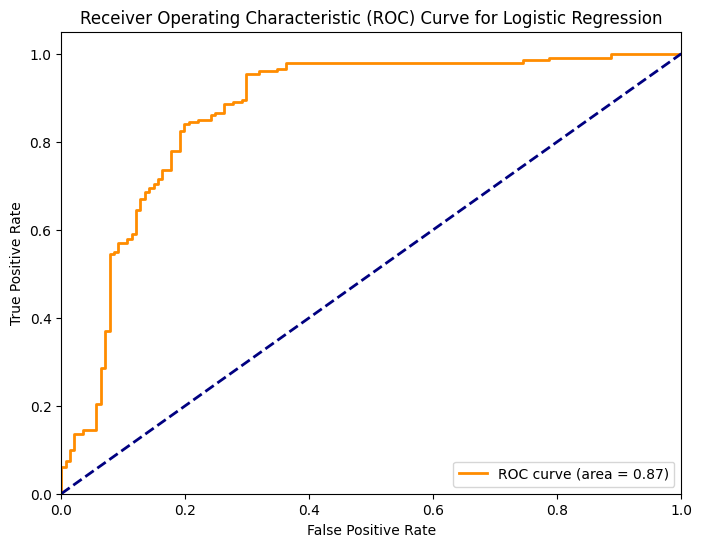

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(Y_test_log, Y_pred_proba_log)
roc_auc = auc(fpr, tpr)

# Plotear la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show()

### 5.2. Tabla de Contingencia del Modelo de Regresión Logística

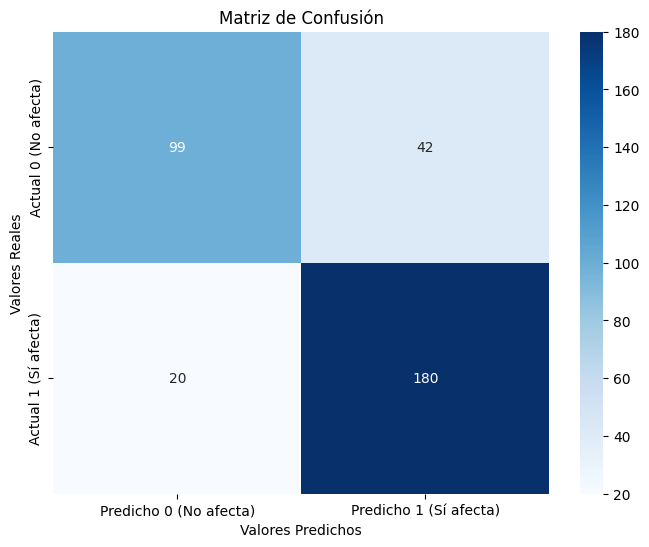

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generar la matriz de confusión
cm = confusion_matrix(Y_test_log, Y_pred_log)

# Plotear la matriz de confusión como un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho 0 (No afecta)', 'Predicho 1 (Sí afecta)'],
            yticklabels=['Actual 0 (No afecta)', 'Actual 1 (Sí afecta)'])
plt.title('Matriz de Confusión')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

Ahora vamos a meter todas las variables en el modelo de regresion logistica

In [24]:
# Definir la variable dependiente (Y) y las independientes (X)
Y_logistic2 = data2['Affects_Academic_Performance']
X_logistic2 = data2[['Sleep_Hours_Per_Night', 'Avg_Daily_Usage_Hours', 'Overall_Impact',
                    'Mental_Health_Score', 'Age', 'Gender', 'Academic_Level']]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_log2, X_test_log2, Y_train_log2, Y_test_log2 = train_test_split(X_logistic2, Y_logistic2, test_size=0.2, random_state=42)

# Crear un DataFrame para el modelo statsmodels que incluya la variable dependiente
train_data_log2 = pd.DataFrame(X_train_log2)
train_data_log2['Affects_Academic_Performance'] = Y_train_log2

# Construir el modelo de regresión logística usando statsmodels
# La fórmula es 'Variable_Dependiente ~ Variable_Independiente1 + Variable_Independiente2'
logistic_model2 = smf.logit('Affects_Academic_Performance ~ Sleep_Hours_Per_Night + Avg_Daily_Usage_Hours + Overall_Impact + Mental_Health_Score + Age + Gender +Academic_Level',
                           data=train_data_log2).fit()

# Imprimir el resumen del modelo
print("\nResumen del Modelo de Regresión Logística:")
print(logistic_model.summary())

# Realizar predicciones en el conjunto de prueba
# Usar 0.5 como umbral para clasificar
Y_pred_proba_log2 = logistic_model.predict(X_test_log2)
Y_pred_log2 = (Y_pred_proba_log2 >= 0.5).astype(int)

# Calcular las métricas de evaluación
accuracy = accuracy_score(Y_test_log2, Y_pred_log2)

print("\nMetricas de Evaluación del Modelo de Regresión Logística:")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(Y_test_log2, Y_pred_log2))

Optimization terminated successfully.
         Current function value: 0.399755
         Iterations 6

Resumen del Modelo de Regresión Logística:
                                Logit Regression Results                                
Dep. Variable:     Affects_Academic_Performance   No. Observations:                 1364
Model:                                    Logit   Df Residuals:                     1359
Method:                                     MLE   Df Model:                            4
Date:                          Mon, 20 Apr 2026   Pseudo R-squ.:                  0.4075
Time:                                  21:24:12   Log-Likelihood:                -545.66
converged:                                 True   LL-Null:                       -920.90
Covariance Type:                      nonrobust   LLR p-value:                4.063e-161
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

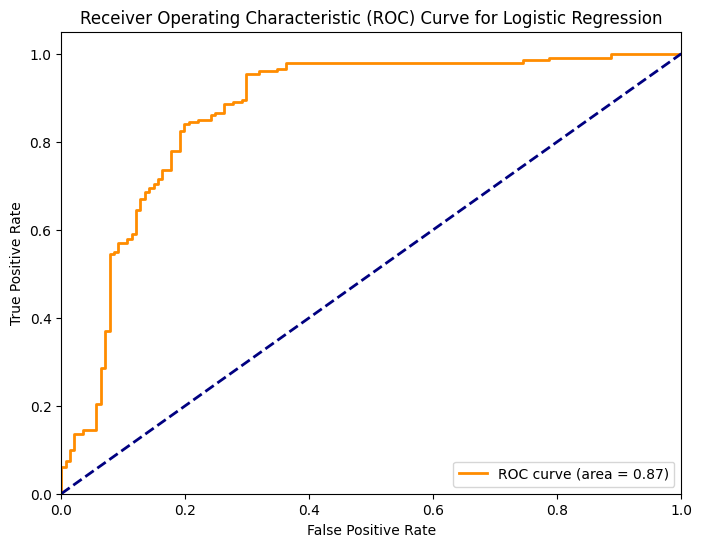

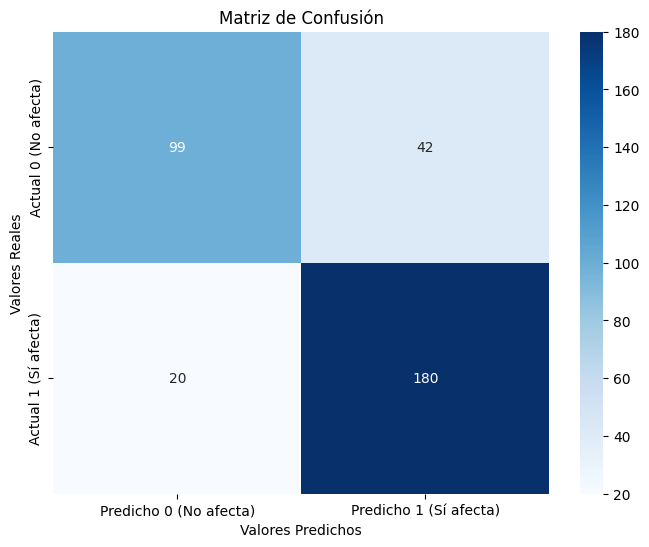

In [25]:
# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(Y_test_log2, Y_pred_proba_log2)
roc_auc2 = auc(fpr, tpr)

# Plotear la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show()

# Generar la matriz de confusión
cm2 = confusion_matrix(Y_test_log2, Y_pred_log2)

# Plotear la matriz de confusión como un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho 0 (No afecta)', 'Predicho 1 (Sí afecta)'],
            yticklabels=['Actual 0 (No afecta)', 'Actual 1 (Sí afecta)'])
plt.title('Matriz de Confusión')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

## 6. Arbol de desicion

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Definir la variable dependiente (Y) y las independientes (X)
Y_dt = data2['Affects_Academic_Performance']
X_dt = data2[['Sleep_Hours_Per_Night', 'Avg_Daily_Usage_Hours', 'Overall_Impact',
                    'Mental_Health_Score', 'Age', 'Gender', 'Academic_Level','Most_Used_Platform']]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_dt, X_test_dt, Y_train_dt, Y_test_dt = train_test_split(X_dt, Y_dt, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=42) # Instanciar el modelo
dt_model.fit(X_train_dt, Y_train_dt) # Entrenar con X_train_dt y Y_train_dt

# Realizar predicciones en el conjunto de prueba
Y_pred_dt = dt_model.predict(X_test_dt)

# Calcular las métricas de evaluación
accuracy = accuracy_score(Y_test_dt, Y_pred_dt)

print("\nMetricas de Evaluación de arbol de desicion:")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(Y_test_dt, Y_pred_dt))


Metricas de Evaluación de arbol de desicion:
Precisión (Accuracy): 0.7742

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72       141
           1       0.80      0.82      0.81       200

    accuracy                           0.77       341
   macro avg       0.77      0.76      0.77       341
weighted avg       0.77      0.77      0.77       341



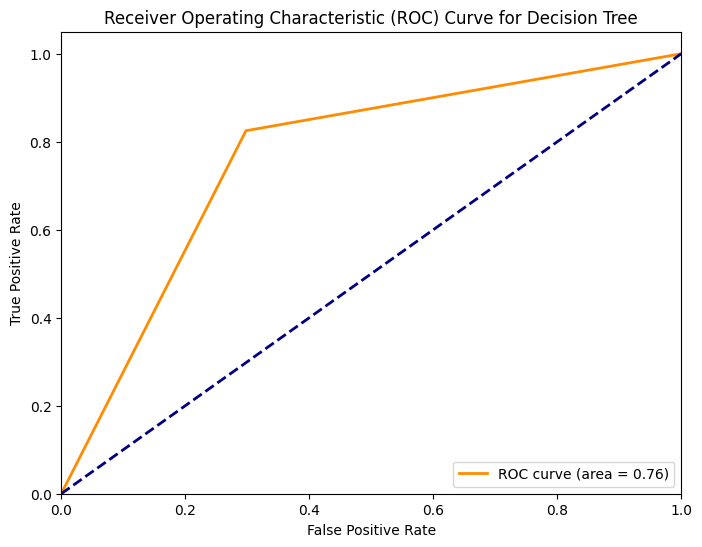

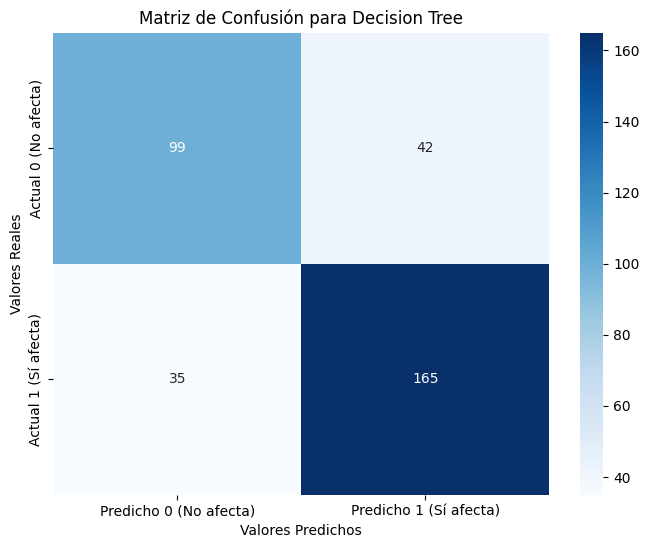

In [27]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate probabilities for the positive class (class 1)
Y_pred_proba_dt = dt_model.predict_proba(X_test_dt)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(Y_test_dt, Y_pred_proba_dt)
roc_auc_dt = auc(fpr, tpr)

# Plotear la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree')
plt.legend(loc='lower right')
plt.show()

# Generar la matriz de confusión
cm_dt = confusion_matrix(Y_test_dt, Y_pred_dt)

# Plotear la matriz de confusión como un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho 0 (No afecta)', 'Predicho 1 (Sí afecta)'],
            yticklabels=['Actual 0 (No afecta)', 'Actual 1 (Sí afecta)'])
plt.title('Matriz de Confusión para Decision Tree')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

## Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Definir la variable dependiente (Y) y las independientes (X)
Y_rf = data2['Affects_Academic_Performance']
X_rf = data2[['Sleep_Hours_Per_Night', 'Avg_Daily_Usage_Hours', 'Overall_Impact',
                    'Mental_Health_Score', 'Age', 'Gender', 'Academic_Level',
                    'Most_Used_Platform']]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_rf, X_test_rf, Y_train_rf, Y_test_rf = train_test_split(X_rf, Y_rf, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de Árbol de Decisión
rf_model = RandomForestClassifier(random_state=42) # Instanciar el modelo
rf_model.fit(X_train_rf, Y_train_rf) # Entrenar con X_train_rf y Y_train_rf

# Realizar predicciones en el conjunto de prueba
Y_pred_rf = rf_model.predict(X_test_rf)

# Calcular las métricas de evaluación
accuracy = accuracy_score(Y_test_rf, Y_pred_rf)

print("\nMetricas de Evaluación de arbol de desicion:")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(Y_test_rf, Y_pred_rf))


Metricas de Evaluación de arbol de desicion:
Precisión (Accuracy): 0.8211

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.72      0.77       141
           1       0.82      0.89      0.85       200

    accuracy                           0.82       341
   macro avg       0.82      0.81      0.81       341
weighted avg       0.82      0.82      0.82       341



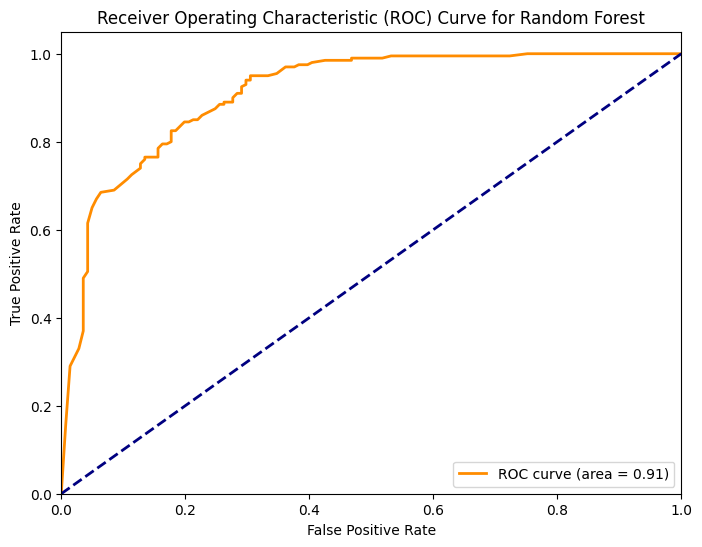

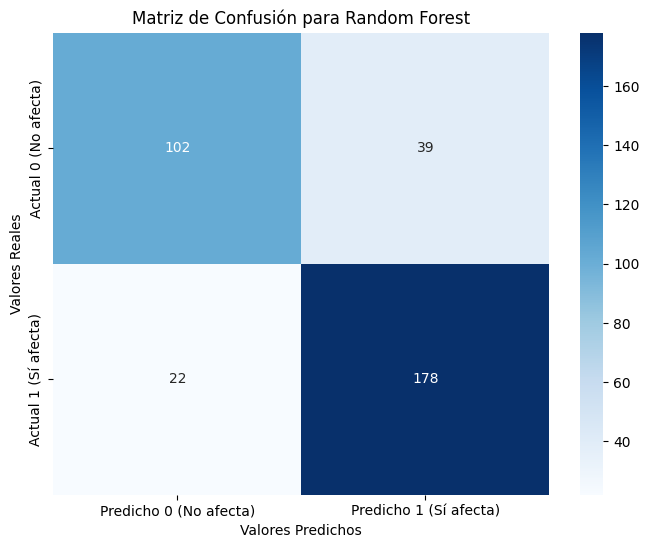

In [29]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate probabilities for the positive class (class 1)
Y_pred_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]

# Calcular la curva ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(Y_test_rf, Y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plotear la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc='lower right')
plt.show()

# Generar la matriz de confusión
cm_rf = confusion_matrix(Y_test_rf, Y_pred_rf)

# Plotear la matriz de confusión como un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho 0 (No afecta)', 'Predicho 1 (Sí afecta)'],
            yticklabels=['Actual 0 (No afecta)', 'Actual 1 (Sí afecta)'])
plt.title('Matriz de Confusión para Random Forest')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

In [30]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Definir la variable dependiente (Y) y las independientes (X)
Y_svc = data2['Affects_Academic_Performance']
X_svc = data2[['Sleep_Hours_Per_Night', 'Avg_Daily_Usage_Hours', 'Overall_Impact',
                    'Mental_Health_Score', 'Age', 'Gender', 'Academic_Level',
                    'Most_Used_Platform']]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_svc, X_test_svc, Y_train_svc, Y_test_svc = train_test_split(X_svc, Y_svc, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de Árbol de Decisión
svc_model = SVC(random_state=42, probability=True) # Instanciar el modelo con probability=True
svc_model.fit(X_train_svc, Y_train_svc) # Entrenar con X_train_svc y Y_train_svc

# Realizar predicciones en el conjunto de prueba
Y_pred_svc = svc_model.predict(X_test_svc)

# Calcular las métricas de evaluación
accuracy = accuracy_score(Y_test_svc, Y_pred_svc)

print("\nMetricas de Evaluación de SVC:")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(Y_test_svc, Y_pred_svc))


Metricas de Evaluación de SVC:
Precisión (Accuracy): 0.8387

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.67      0.78       141
           1       0.81      0.95      0.87       200

    accuracy                           0.84       341
   macro avg       0.86      0.81      0.82       341
weighted avg       0.85      0.84      0.83       341



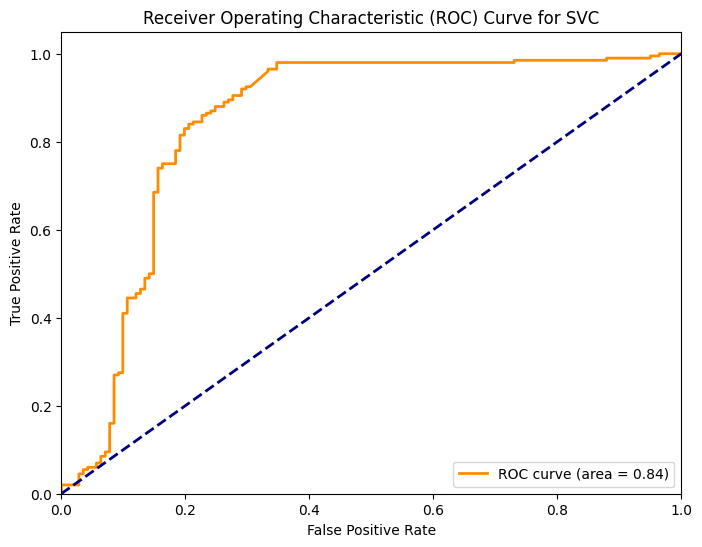

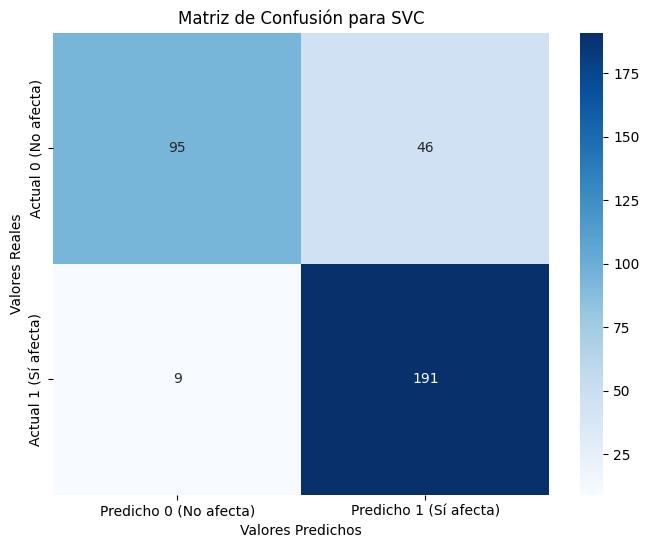

In [31]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate probabilities for the positive class (class 1)
Y_pred_proba_svc = svc_model.predict_proba(X_test_svc)[:, 1]

# Calcular la curva ROC
fpr_svc, tpr_svc, thresholds_svc = roc_curve(Y_test_svc, Y_pred_proba_svc)
roc_auc_svc = auc(fpr_svc, tpr_svc)

# Plotear la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_svc, tpr_svc, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_svc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVC')
plt.legend(loc='lower right')
plt.show()

# Generar la matriz de confusión
cm_svc = confusion_matrix(Y_test_svc, Y_pred_svc)

# Plotear la matriz de confusión como un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho 0 (No afecta)', 'Predicho 1 (Sí afecta)'],
            yticklabels=['Actual 0 (No afecta)', 'Actual 1 (Sí afecta)'])
plt.title('Matriz de Confusión para SVC')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

## Cambio de variable OVERAL IMPACT

In [32]:
data3 = data2.copy()

# Convert 'Overall_Impact' to a dichotomous variable:
# 0 for Negative, 1 for Neutral/Positive
data3['Overall_Impact_Dichotomous'] = data3['Overall_Impact'].apply(lambda x: 0 if x == 0 else 1)

# Drop the original 'Overall_Impact' column if desired, or keep it.
# For a classification model focusing on a binary outcome, it's often good to replace or clearly distinguish.
# Let's keep both for now, but focus on the new dichotomous one for classification.

print("First 5 rows of data3 with the new dichotomous 'Overall_Impact_Dichotomous' variable:")
display(data3.head())
print("\nValue counts for the new 'Overall_Impact_Dichotomous' variable:")
display(data3['Overall_Impact_Dichotomous'].value_counts())

First 5 rows of data3 with the new dichotomous 'Overall_Impact_Dichotomous' variable:


,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Sleep_Hours_Per_Night,Affects_Academic_Performance,Overall_Impact,Mental_Health_Score,Overall_Impact_Dichotomous
0,21,0,1,4.0,2,6.7,0,1,6.8,1
1,23,1,1,1.6,3,8.6,0,2,7.6,1
2,22,0,2,4.6,0,6.7,0,1,7.0,1
3,18,0,1,7.0,6,5.4,1,0,5.3,0
4,24,1,0,7.5,2,5.0,1,0,4.4,0



Value counts for the new 'Overall_Impact_Dichotomous' variable:


,count
Overall_Impact_Dichotomous,
0,939
1,766


In [36]:
import pandas as pd

# Calculate absolute frequencies
absolute_frequencies_dichotomous = data3['Overall_Impact_Dichotomous'].value_counts()

# Calculate relative frequencies (percentages)
relative_frequencies_dichotomous = data3['Overall_Impact_Dichotomous'].value_counts(normalize=True) * 100

# Create a frequency table DataFrame
frequency_table_dichotomous = pd.DataFrame({
    'Frecuencia Absoluta': absolute_frequencies_dichotomous,
    'Frecuencia Relativa (%)': relative_frequencies_dichotomous
})

# Map the 0 and 1 values to descriptive labels for better readability
frequency_table_dichotomous.index = frequency_table_dichotomous.index.map({0: 'Negative Impact', 1: 'Non-Negative Impact'})

print("Tabla de Frecuencia para 'Overall_Impact_Dichotomous':")
display(frequency_table_dichotomous.round(2))

Tabla de Frecuencia para 'Overall_Impact_Dichotomous':


,Frecuencia Absoluta,Frecuencia Relativa (%)
Overall_Impact_Dichotomous,,
Negative Impact,939,55.07
Non-Negative Impact,766,44.93


Optimization terminated successfully.
         Current function value: 0.176094
         Iterations 9

Resumen del Modelo de Regresión Logística (Overall_Impact_Dichotomous):
                               Logit Regression Results                               
Dep. Variable:     Overall_Impact_Dichotomous   No. Observations:                 1364
Model:                                  Logit   Df Residuals:                     1356
Method:                                   MLE   Df Model:                            7
Date:                        Mon, 20 Apr 2026   Pseudo R-squ.:                  0.7445
Time:                                22:09:15   Log-Likelihood:                -240.19
converged:                               True   LL-Null:                       -940.17
Covariance Type:                    nonrobust   LLR p-value:                3.956e-298
                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

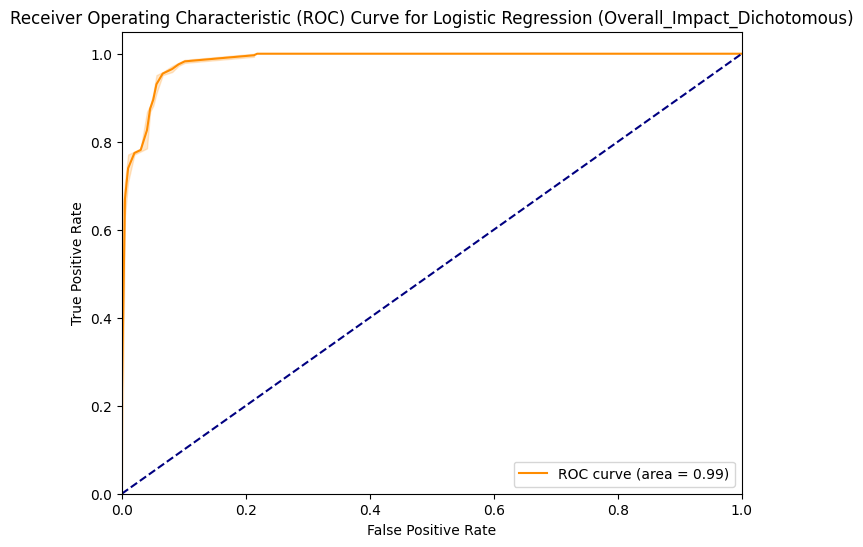

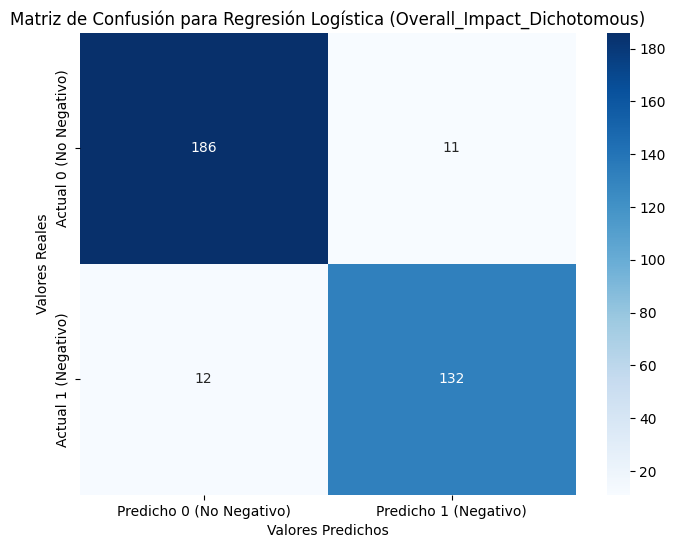

In [38]:
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definir la variable dependiente (Y) y las independientes (X)
Y_logistic3 = data3['Overall_Impact_Dichotomous']
X_logistic3 = data3[['Sleep_Hours_Per_Night', 'Avg_Daily_Usage_Hours', 'Mental_Health_Score',
                     'Age', 'Gender', 'Academic_Level', 'Most_Used_Platform']]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_log3, X_test_log3, Y_train_log3, Y_test_log3 = train_test_split(X_logistic3, Y_logistic3, test_size=0.2, random_state=42)

# Crear un DataFrame para el modelo statsmodels que incluya la variable dependiente
train_data_log3 = pd.DataFrame(X_train_log3)
train_data_log3['Overall_Impact_Dichotomous'] = Y_train_log3

# Construir el modelo de regresión logística usando statsmodels
formula_log3 = 'Overall_Impact_Dichotomous ~ Sleep_Hours_Per_Night + Avg_Daily_Usage_Hours + Mental_Health_Score + Age + Gender + Academic_Level + Most_Used_Platform'
logistic_model3 = smf.logit(formula_log3, data=train_data_log3).fit()

# Imprimir el resumen del modelo
print("\nResumen del Modelo de Regresión Logística (Overall_Impact_Dichotomous):")
print(logistic_model3.summary())

# Realizar predicciones en el conjunto de prueba
# Usar 0.5 como umbral para clasificar
Y_pred_proba_log3 = logistic_model3.predict(X_test_log3)
Y_pred_log3 = (Y_pred_proba_log3 >= 0.5).astype(int)

# Calcular las métricas de evaluación
accuracy_log3 = accuracy_score(Y_test_log3, Y_pred_log3)

print("\nMetricas de Evaluación del Modelo de Regresión Logística:")
print(f"Precisión (Accuracy): {accuracy_log3:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(Y_test_log3, Y_pred_log3))

# Calcular la curva ROC
fpr_log3, tpr_log3, thresholds_log3 = roc_curve(Y_test_log3, Y_pred_proba_log3)
roc_auc_log3 = auc(fpr_log3, tpr_log3)

# Plotear la curva ROC
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr_log3, y=tpr_log3, label=f'ROC curve (area = {roc_auc_log3:.2f})', color='darkorange')
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', color='navy')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression (Overall_Impact_Dichotomous)')
plt.legend(loc='lower right')
plt.show()

# Generar la matriz de confusión
cm_log3 = confusion_matrix(Y_test_log3, Y_pred_log3)

# Plotear la matriz de confusión como un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho 0 (No Negativo)', 'Predicho 1 (Negativo)'],
            yticklabels=['Actual 0 (No Negativo)', 'Actual 1 (Negativo)'])
plt.title('Matriz de Confusión para Regresión Logística (Overall_Impact_Dichotomous)')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

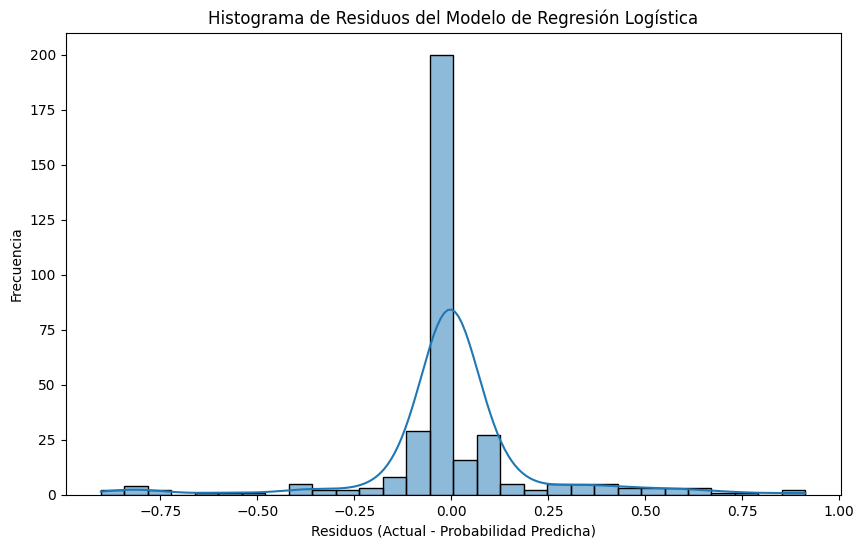

In [40]:
residuals_log3 = Y_test_log3 - Y_pred_proba_log3

plt.figure(figsize=(10, 6))
sns.histplot(residuals_log3, kde=True, bins=30)
plt.title('Histograma de Residuos del Modelo de Regresión Logística')
plt.xlabel('Residuos (Actual - Probabilidad Predicha)')
plt.ylabel('Frecuencia')
plt.show()

First 5 rows of data4 with the new binary 'Overall_Impact_Binary' variable:


,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Sleep_Hours_Per_Night,Affects_Academic_Performance,Overall_Impact,Mental_Health_Score,Overall_Impact_Binary
0,21,0,1,4.0,2,6.7,0,1,6.8,1
1,23,1,1,1.6,3,8.6,0,2,7.6,1
2,22,0,2,4.6,0,6.7,0,1,7.0,1
3,18,0,1,7.0,6,5.4,1,0,5.3,0
4,24,1,0,7.5,2,5.0,1,0,4.4,0



Value counts for the new 'Overall_Impact_Binary' variable:


,count
Overall_Impact_Binary,
0,939
1,766


Optimization terminated successfully.
         Current function value: 0.176094
         Iterations 9

Resumen del Modelo de Regresión Logística (Overall_Impact_Binary):

                             Logit Regression Results                            
Dep. Variable:     Overall_Impact_Binary   No. Observations:                 1364
Model:                             Logit   Df Residuals:                     1356
Method:                              MLE   Df Model:                            7
Date:                   Mon, 20 Apr 2026   Pseudo R-squ.:                  0.7445
Time:                           23:39:02   Log-Likelihood:                -240.19
converged:                          True   LL-Null:                       -940.17
Covariance Type:               nonrobust   LLR p-value:                3.956e-298
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

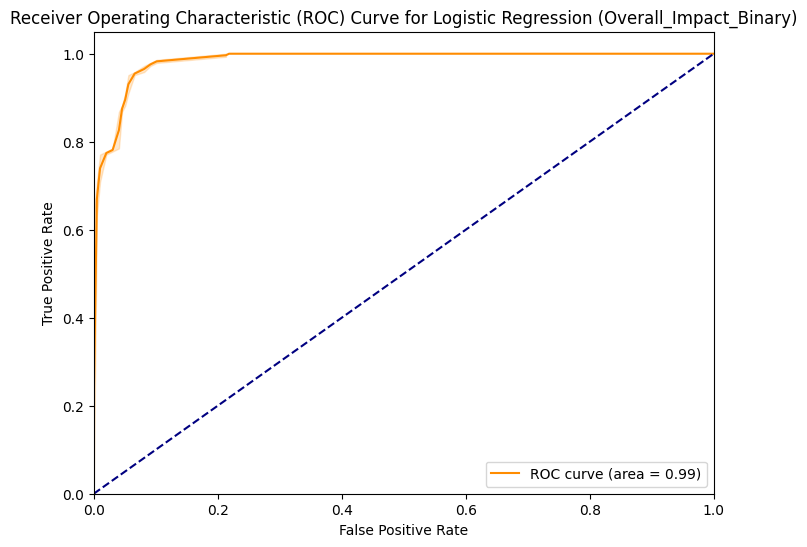

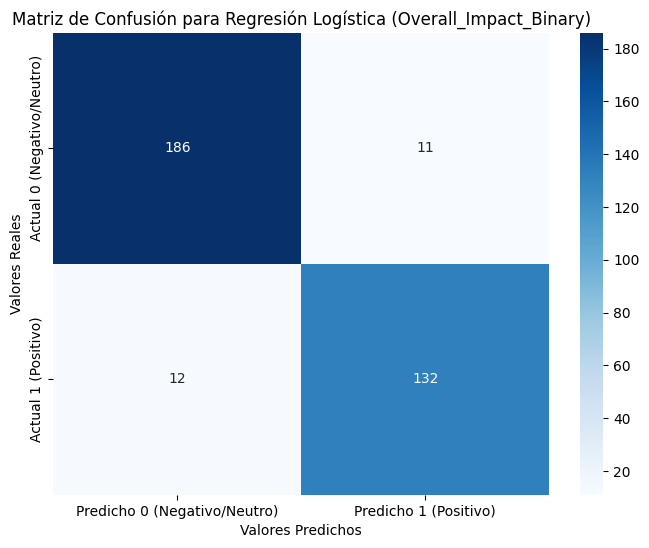

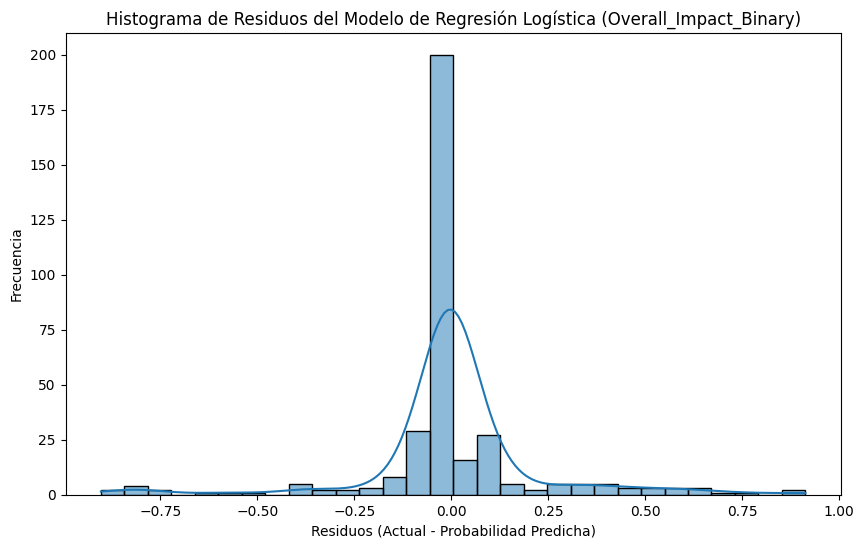

In [41]:
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create data4 by transforming Overall_Impact from data2
data4 = data2.copy()
# Overall_Impact in data2 is encoded as: Negative: 0, Neutral: 1, Positive: 2
# We want: 0 for Negative, 1 for Neutral/Positive
data4['Overall_Impact_Binary'] = data4['Overall_Impact'].apply(lambda x: 0 if x == 0 else 1)

print("First 5 rows of data4 with the new binary 'Overall_Impact_Binary' variable:")
display(data4.head())
print("\nValue counts for the new 'Overall_Impact_Binary' variable:")
display(data4['Overall_Impact_Binary'].value_counts())

# 2. Define the dependent variable (Y) and the independent variables (X)
Y_logistic4 = data4['Overall_Impact_Binary']
X_logistic4 = data4[['Sleep_Hours_Per_Night', 'Avg_Daily_Usage_Hours', 'Mental_Health_Score',
                     'Age', 'Gender', 'Academic_Level', 'Most_Used_Platform']]

# 3. Split the data into training and testing sets
X_train_log4, X_test_log4, Y_train_log4, Y_test_log4 = train_test_split(X_logistic4, Y_logistic4, test_size=0.2, random_state=42)

# 4. Create a DataFrame for the statsmodels model that includes the dependent variable
train_data_log4 = pd.DataFrame(X_train_log4)
train_data_log4['Overall_Impact_Binary'] = Y_train_log4

# 5. Build and train the logistic regression model using statsmodels
formula_log4 = 'Overall_Impact_Binary ~ Sleep_Hours_Per_Night + Avg_Daily_Usage_Hours + Mental_Health_Score + Age + Gender + Academic_Level + Most_Used_Platform'
logistic_model4 = smf.logit(formula_log4, data=train_data_log4).fit()

# Imprimir el resumen del modelo
print("\nResumen del Modelo de Regresión Logística (Overall_Impact_Binary):\n")
print(logistic_model4.summary())

# 6. Realizar predicciones en el conjunto de prueba
# Usar 0.5 como umbral para clasificar
Y_pred_proba_log4 = logistic_model4.predict(X_test_log4)
Y_pred_log4 = (Y_pred_proba_log4 >= 0.5).astype(int)

# 7. Calcular las métricas de evaluación
accuracy_log4 = accuracy_score(Y_test_log4, Y_pred_log4)

print("\nMetricas de Evaluación del Modelo de Regresión Logística:\n")
print(f"Precisión (Accuracy): {accuracy_log4:.4f}")
print("\nInforme de Clasificación:\n")
print(classification_report(Y_test_log4, Y_pred_log4))

# 8. Calcular y plotear la curva ROC y AUC
fpr_log4, tpr_log4, thresholds_log4 = roc_curve(Y_test_log4, Y_pred_proba_log4)
roc_auc_log4 = auc(fpr_log4, tpr_log4)

plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr_log4, y=tpr_log4, label=f'ROC curve (area = {roc_auc_log4:.2f})', color='darkorange')
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', color='navy')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression (Overall_Impact_Binary)')
plt.legend(loc='lower right')
plt.show()

# 9. Generar la matriz de confusión
cm_log4 = confusion_matrix(Y_test_log4, Y_pred_log4)

# Plotear la matriz de confusión como un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log4, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho 0 (Negativo/Neutro)', 'Predicho 1 (Positivo)'],
            yticklabels=['Actual 0 (Negativo/Neutro)', 'Actual 1 (Positivo)'])
plt.title('Matriz de Confusión para Regresión Logística (Overall_Impact_Binary)')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

# 10. Calcular residuos y plotear un histograma de ellos
residuals_log4 = Y_test_log4 - Y_pred_proba_log4

plt.figure(figsize=(10, 6))
sns.histplot(residuals_log4, kde=True, bins=30)
plt.title('Histograma de Residuos del Modelo de Regresión Logística (Overall_Impact_Binary)')
plt.xlabel('Residuos (Actual - Probabilidad Predicha)')
plt.ylabel('Frecuencia')
plt.show()